# Анализ систем накопления энергии в гибридной микросети

# 1. Введение

В работе рассматривается гибридная микросеть Rye/Froan (Норвегия), включающая:
- солнечную генерацию,
- ветровую генерацию,
- аккумуляторную батарею,
- водородную систему хранения энергии,
- подключение к внешней электрической сети.

Исследование выполняется на основе реальных временных рядов потребления и генерации.

Основная задача моделирования — исследование различных стратегий управления накопителями энергии и оценка их влияния на:
- потребление энергии из внешней сети;
- стоимость электроэнергии;
- величину пиковых нагрузок;
- сезонные особенности работы системы.

В работе рассматриваются следующие стратегии:
1. Always — заряд при избытке генерации и разряд при дефиците;
2. Peak Shaving — сглаживание пиков результирующей нагрузки;
3. Time-of-Day (TOD) — использование накопителей в часы максимальной нагрузки.

---

# 2. Импорт библиотек

Для обработки временных рядов, моделирования системы и визуализации результатов используются библиотеки:
- pandas,
- numpy,
- matplotlib,
- seaborn.

In [1]:
# ИМПОРТ БИБЛИОТЕК

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.dates import DateFormatter

import warnings
warnings.filterwarnings('ignore')

In [2]:
# НАСТРОЙКА ОТОБРАЖЕНИЯ ГРАФИКОВ

plt.style.use('seaborn-v0_8-darkgrid')

sns.set_palette('husl')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# 3. Загрузка и подготовка данных

Для моделирования используется исходный файл `train.csv`, содержащий:
- временные метки,
- нагрузку микросети,
- солнечную генерацию,
- ветровую генерацию,
- рыночную стоимость электроэнергии.

На этапе подготовки данных выполняются:
- преобразование временных меток,
- переименование столбцов,
- создание временных признаков,
- вычисление суммарной генерации ВИЭ,
- расчет результирующей нагрузки на систему хранения.

Результирующая нагрузка определяется как разность между потреблением и генерацией:

$$
P_{net} = P_{load} - (P_{PV} + P_{wind})
$$

где:

- $P_{net}$ — результирующая нагрузка микросети;
- $P_{load}$ — потребляемая мощность;
- $P_{PV}$ — мощность солнечной генерации;
- $P_{wind}$ — мощность ветровой генерации.

При:
- $P_{net} > 0$ — наблюдается дефицит энергии;
- $P_{net} < 0$ — наблюдается избыток генерации.

Положительное значение `net_load` соответствует дефициту энергии.

Отрицательное значение `net_load` соответствует избытку генерации.

In [3]:
# ЗАГРУЗКА ДАННЫХ

# Исходный файл из репозитория
df = pd.read_csv('train.csv')

In [4]:
# ПРЕОБРАЗОВАНИЕ ВРЕМЕНИ

# Преобразование timestamp в datetime
df['timestamp'] = pd.to_datetime(df['time'])

In [5]:
# ПЕРЕИМЕНОВАНИЕ КОЛОНОК

df = df.rename(columns={

    'consumption': 'load',
    'pv_production': 'pv_generation',
    'wind_production': 'wind_generation',
    'spot_market_price': 'spot_price'

})

In [6]:
# СОРТИРОВКА ПО ВРЕМЕНИ

df = df.sort_values('timestamp').reset_index(drop=True)

In [7]:
# ВРЕМЕННЫЕ ПРИЗНАКИ

df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day
df['month'] = df['timestamp'].dt.month
df['date'] = df['timestamp'].dt.date

In [8]:
# СУММАРНАЯ ГЕНЕРАЦИЯ ВИЭ

# Общая генерация:
# солнечная + ветровая

df['res_generation'] = (

    df['pv_generation'] +
    df['wind_generation']

)

In [9]:
# РЕЗУЛЬТИРУЮЩАЯ НАГРУЗКА

# Положительное значение:
# дефицит энергии

# Отрицательное значение:
# избыток генерации

df['net_load'] = (

    df['load'] -
    df['res_generation']

)

In [10]:
# ТАРИФНАЯ МОДЕЛЬ

ENERGY_TARIFF = 0.05
PEAK_TARIFF = 49.0

# итоговая цена энергии из сети
df["energy_cost_NOK"] = df["spot_price"] + ENERGY_TARIFF

In [11]:
# ПРОВЕРКА ДАННЫХ

print('Количество строк:', len(df))

print('\nКолонки:')

print(df.columns)

print('\nПервые строки:')

display(df.head())

Количество строк: 9515

Колонки:
Index(['time', 'pv_generation', 'wind_generation', 'load', 'spot_price',
       'precip_1h:mm', 'precip_type:idx', 'prob_precip_1h:p',
       'clear_sky_rad:W', 'clear_sky_energy_1h:J', 'diffuse_rad:W',
       'diffuse_rad_1h:Wh', 'direct_rad:W', 'direct_rad_1h:Wh', 'global_rad:W',
       'global_rad_1h:Wh', 'sunshine_duration_1h:min', 'sun_azimuth:d',
       'sun_elevation:d', 'low_cloud_cover:p', 'medium_cloud_cover:p',
       'high_cloud_cover:p', 'total_cloud_cover:p', 'effective_cloud_cover:p',
       'temp', 'relative_humidity_2m:p', 'dew_point_2m:C', 'wind_speed_2m:ms',
       'wind_dir_2m:d', 't_10m:C', 'relative_humidity_10m:p',
       'dew_point_10m:C', 'wind_speed_10m:ms', 'wind_dir_10m:d', 't_50m:C',
       'relative_humidity_50m:p', 'dew_point_50m:C', 'wind_speed_50m:ms',
       'wind_dir_50m:d', 't_100m:C', 'relative_humidity_100m:p',
       'dew_point_100m:C', 'wind_speed_100m:ms', 'wind_dir_100m:d',
       'timestamp', 'hour', 'day', 'mo

,time,pv_generation,wind_generation,load,spot_price,precip_1h:mm,precip_type:idx,prob_precip_1h:p,clear_sky_rad:W,clear_sky_energy_1h:J,...,wind_speed_100m:ms,wind_dir_100m:d,timestamp,hour,day,month,date,res_generation,net_load,energy_cost_NOK
0,2020-01-01 13:00:00,0.0,40.59,26.514689,0.28969,0.0,0.0,1.0,10.0,64826.0,...,10.4,247.3,2020-01-01 13:00:00,13,1,1,2020-01-01,40.59,-14.075311,0.33969
1,2020-01-01 14:00:00,0.0,67.86,28.326960,0.29561,0.0,0.0,1.0,0.0,8961.1,...,10.0,252.1,2020-01-01 14:00:00,14,1,1,2020-01-01,67.86,-39.533040,0.34561
2,2020-01-01 15:00:00,0.0,116.68,23.682207,0.30044,0.0,0.0,1.0,0.0,0.0,...,11.7,253.8,2020-01-01 15:00:00,15,1,1,2020-01-01,116.68,-92.997793,0.35044
3,2020-01-01 16:00:00,0.0,120.22,25.354782,0.29975,0.0,0.0,1.0,0.0,0.0,...,14.3,254.2,2020-01-01 16:00:00,16,1,1,2020-01-01,120.22,-94.865218,0.34975
4,2020-01-01 17:00:00,0.0,109.86,23.861942,0.29650,0.0,0.0,1.0,0.0,0.0,...,13.9,249.7,2020-01-01 17:00:00,17,1,1,2020-01-01,109.86,-85.998058,0.34650


# 4. Первичный анализ энергетического баланса

Перед моделированием накопителей необходимо проанализировать исходный энергетический баланс микросети без использования систем хранения энергии.

На данном этапе исследуются:
- профиль потребления,
- профиль солнечной генерации,
- профиль ветровой генерации,
- результирующая нагрузка на систему хранения,
- сезонные особенности дефицита и избытка энергии.

Такой анализ позволяет:
- определить характер работы микросети,
- выявить периоды максимальных нагрузок,
- определить часы избытка генерации,
- обосновать необходимость использования накопителей энергии.

---

## 4.1 Определение сезона

In [12]:
# ОПРЕДЕЛЕНИЕ СЕЗОНА

def get_season(month):

    if month in [12, 1, 2]:
        return 'Winter'

    elif month in [3, 4, 5]:
        return 'Spring'

    elif month in [6, 7, 8]:
        return 'Summer'

    else:
        return 'Autumn'


# Добавление сезона в таблицу

df['season'] = df['month'].apply(get_season)

In [13]:
# БАЗОВАЯ СТАТИСТИКА

total_load = df['load'].sum()

total_pv = df['pv_generation'].sum()

total_wind = df['wind_generation'].sum()

total_res = df['res_generation'].sum()

deficit_hours = (df['net_load'] > 0).sum()

surplus_hours = (df['net_load'] < 0).sum()

print('ОБЩАЯ СТАТИСТИКА')

print(f'Общее потребление: {total_load/1000:.2f} МВт·ч')

print(f'Солнечная генерация: {total_pv/1000:.2f} МВт·ч')

print(f'Ветровая генерация: {total_wind/1000:.2f} МВт·ч')

print(f'Суммарная генерация ВИЭ: {total_res/1000:.2f} МВт·ч')

print(f'Доля ВИЭ: {100 * total_res / total_load:.1f} %')

print(f'Часы дефицита: {deficit_hours}')

print(f'Часы избытка генерации: {surplus_hours}')

ОБЩАЯ СТАТИСТИКА
Общее потребление: 192.79 МВт·ч
Солнечная генерация: 72.83 МВт·ч
Ветровая генерация: 202.24 МВт·ч
Суммарная генерация ВИЭ: 275.07 МВт·ч
Доля ВИЭ: 142.7 %
Часы дефицита: 5515
Часы избытка генерации: 4000


## 4.2 Анализ нагрузки и генерации

На данном этапе выполняется визуальный анализ:
- потребления электроэнергии,
- солнечной генерации,
- ветровой генерации,
- суммарной генерации ВИЭ,
- результирующей нагрузки.

Это позволяет определить:
- периоды максимального потребления,
- характер работы солнечной и ветровой генерации,
- интервалы возникновения избытка энергии,
- необходимость использования накопителей.

In [14]:
# ВЫБОР ПЕРИОДА ДЛЯ ВИЗУАЛИЗАЦИИ

# Для годового графика линии плохо читаются,
# поэтому анализ выполняется на интервале 14 суток

start_date = '2020-07-01'
end_date = '2020-07-15'

mask = (

    (df['timestamp'] >= start_date) &
    (df['timestamp'] <= end_date)

)

df_plot = df[mask]

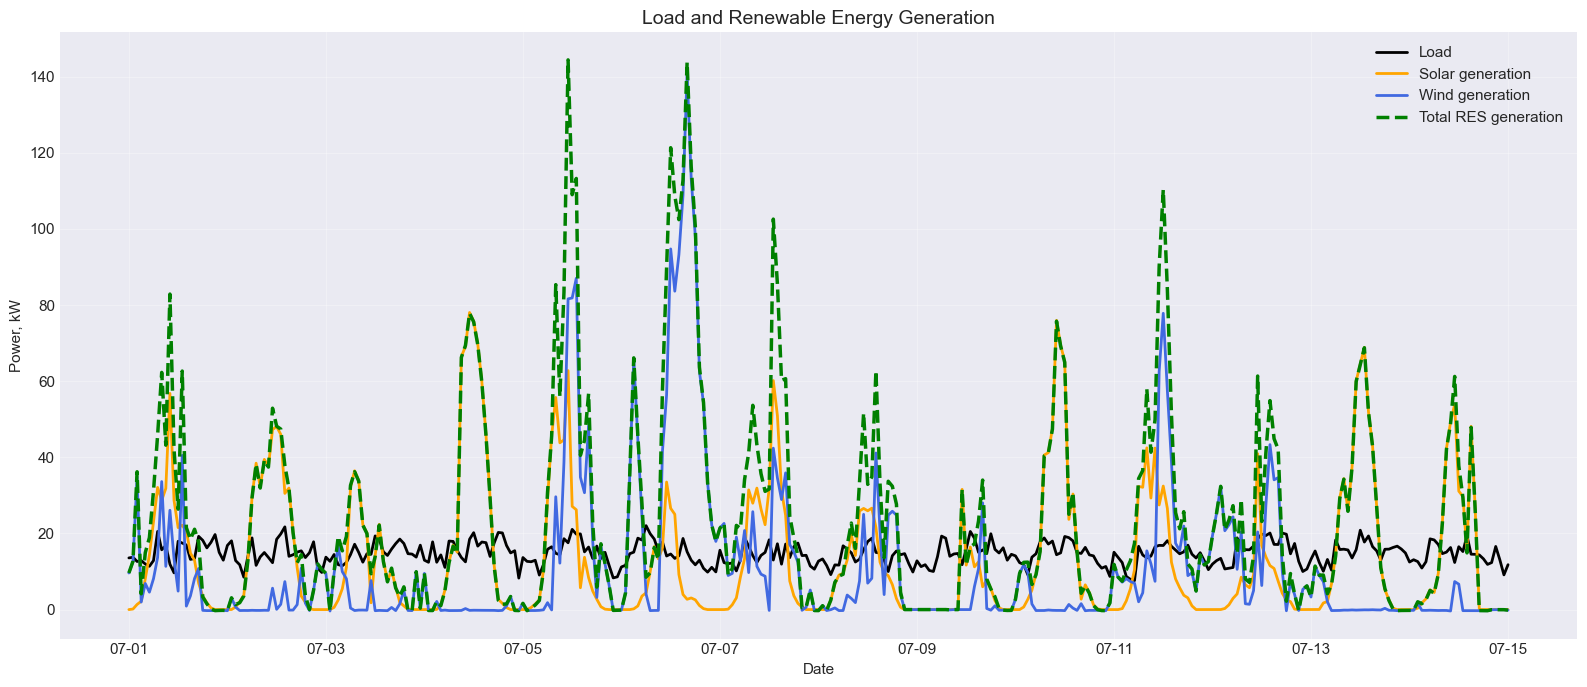

In [15]:
# ГРАФИК НАГРУЗКИ И ГЕНЕРАЦИИ

fig, ax = plt.subplots(figsize=(16, 7))

# ПОТРЕБЛЕНИЕ

ax.plot(

    df_plot['timestamp'],
    df_plot['load'],

    label='Load',
    linewidth=2,
    color='black'

)


# СОЛНЕЧНАЯ ГЕНЕРАЦИЯ

ax.plot(

    df_plot['timestamp'],
    df_plot['pv_generation'],

    label='Solar generation',
    linewidth=2,
    color='orange'

)

# ВЕТРОВАЯ ГЕНЕРАЦИЯ

ax.plot(

    df_plot['timestamp'],
    df_plot['wind_generation'],

    label='Wind generation',
    linewidth=2,
    color='royalblue'

)

# СУММАРНАЯ ГЕНЕРАЦИЯ ВИЭ

ax.plot(

    df_plot['timestamp'],
    df_plot['res_generation'],

    label='Total RES generation',
    linewidth=2.5,
    linestyle='--',
    color='green'

)

# ОФОРМЛЕНИЕ

ax.set_title(

    'Load and Renewable Energy Generation',
    fontsize=14

)

ax.set_xlabel('Date')

ax.set_ylabel('Power, kW')

ax.legend(loc='upper right')

ax.grid(True, alpha=0.3)

ax.xaxis.set_major_formatter(DateFormatter('%m-%d'))

plt.tight_layout()

plt.show()

## 4.3 Анализ результирующей нагрузки (net load)

Результирующая нагрузка показывает разницу между потреблением и суммарной генерацией ВИЭ.

$$
P_{net} = P_{load} - (P_{PV} + P_{wind})
$$

Именно величина `net_load` определяет:
- необходимость покупки энергии из внешней сети;
- возможность зарядки накопителей;
- периоды дефицита и избытка энергии.

Положительные значения соответствуют дефициту энергии.

Отрицательные значения соответствуют избытку генерации.

Для анализа используются:
- временной график net load;
- суточный профиль;
- распределение по сезонам.

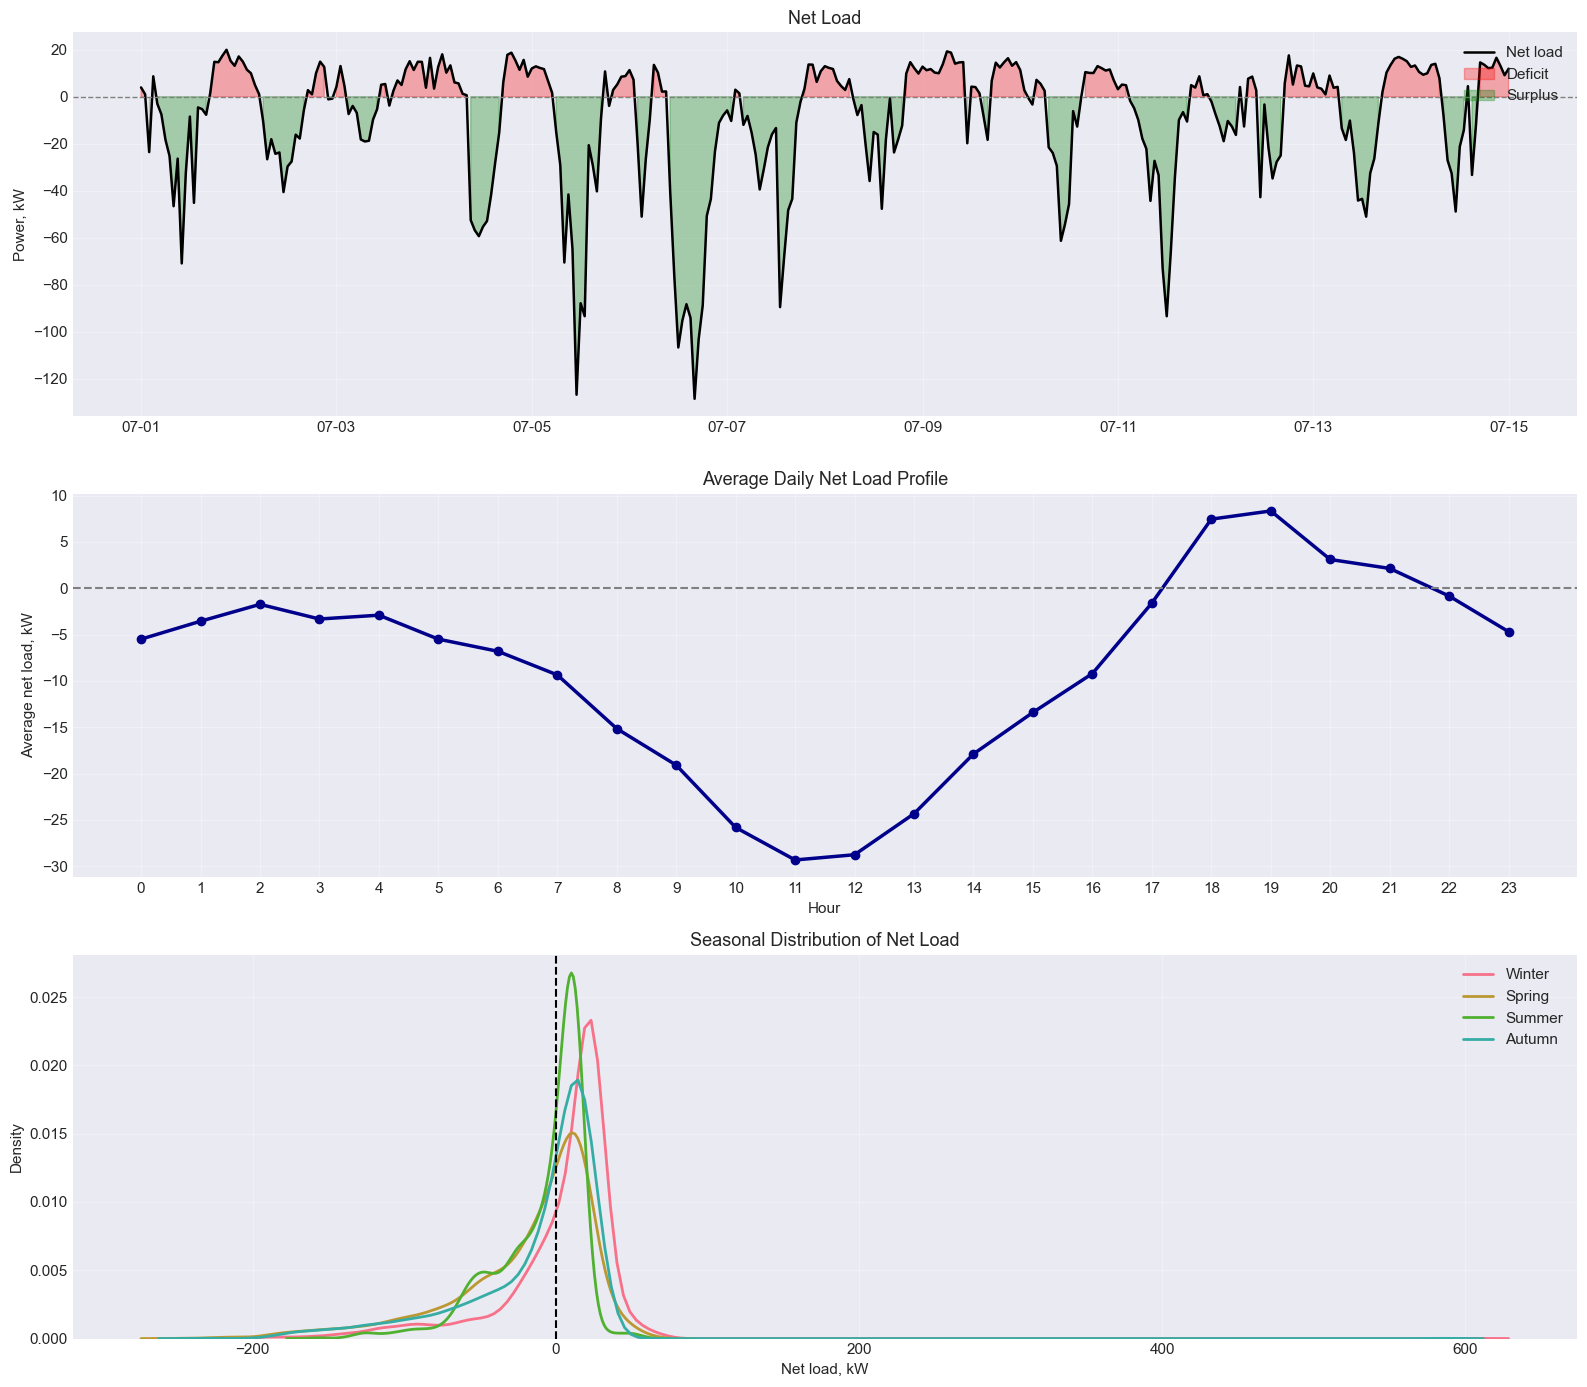

In [16]:
# ГРАФИКИ NET LOAD

fig, axes = plt.subplots(

    3, 1,
    figsize=(16, 14)

)

# 1. ВРЕМЕННОЙ ГРАФИК NET LOAD

ax = axes[0]

ax.plot(

    df_plot['timestamp'],
    df_plot['net_load'],

    color='black',
    linewidth=1.8,
    label='Net load'

)

# ОБЛАСТИ ДЕФИЦИТА

ax.fill_between(

    df_plot['timestamp'],
    0,
    df_plot['net_load'],

    where=(df_plot['net_load'] > 0),

    color='red',
    alpha=0.3,
    label='Deficit'

)

# ОБЛАСТИ ИЗБЫТКА

ax.fill_between(

    df_plot['timestamp'],
    0,
    df_plot['net_load'],

    where=(df_plot['net_load'] < 0),

    color='green',
    alpha=0.3,
    label='Surplus'

)

ax.axhline(

    y=0,
    color='gray',
    linestyle='--',
    linewidth=1

)

ax.set_title('Net Load')

ax.set_ylabel('Power, kW')

ax.legend(loc='upper right')

ax.grid(True, alpha=0.3)

ax.xaxis.set_major_formatter(DateFormatter('%m-%d'))

# 2. СУТОЧНЫЙ ПРОФИЛЬ NET LOAD

ax = axes[1]

hourly_net = (

    df.groupby('hour')['net_load']
    .mean()

)

ax.plot(

    hourly_net.index,
    hourly_net.values,

    marker='o',
    linewidth=2.5,
    color='darkblue'

)

ax.axhline(

    y=0,
    color='gray',
    linestyle='--'

)

ax.set_title('Average Daily Net Load Profile')

ax.set_xlabel('Hour')

ax.set_ylabel('Average net load, kW')

ax.set_xticks(range(24))

ax.grid(True, alpha=0.3)

# 3. РАСПРЕДЕЛЕНИЕ NET LOAD ПО СЕЗОНАМ

ax = axes[2]

for season in ['Winter', 'Spring', 'Summer', 'Autumn']:

    season_data = df[df['season'] == season]

    sns.kdeplot(

        season_data['net_load'],

        ax=ax,
        linewidth=2,
        label=season

    )

ax.axvline(

    x=0,
    color='black',
    linestyle='--'

)

ax.set_title('Seasonal Distribution of Net Load')

ax.set_xlabel('Net load, kW')

ax.set_ylabel('Density')

ax.legend()

ax.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

## 4.4 Тепловая карта результирующей нагрузки

Для анализа сезонных и суточных закономерностей была построена тепловая карта средней результирующей нагрузки.

По оси X отображаются часы суток.

По оси Y отображаются месяцы года.

Цвет показывает среднее значение результирующей нагрузки:

- красные области соответствуют дефициту энергии,
- синие области соответствуют избытку генерации.

Тепловая карта позволяет определить:
- периоды максимальной нагрузки,
- сезонные изменения генерации,
- наиболее эффективные интервалы для зарядки и разрядки накопителей.

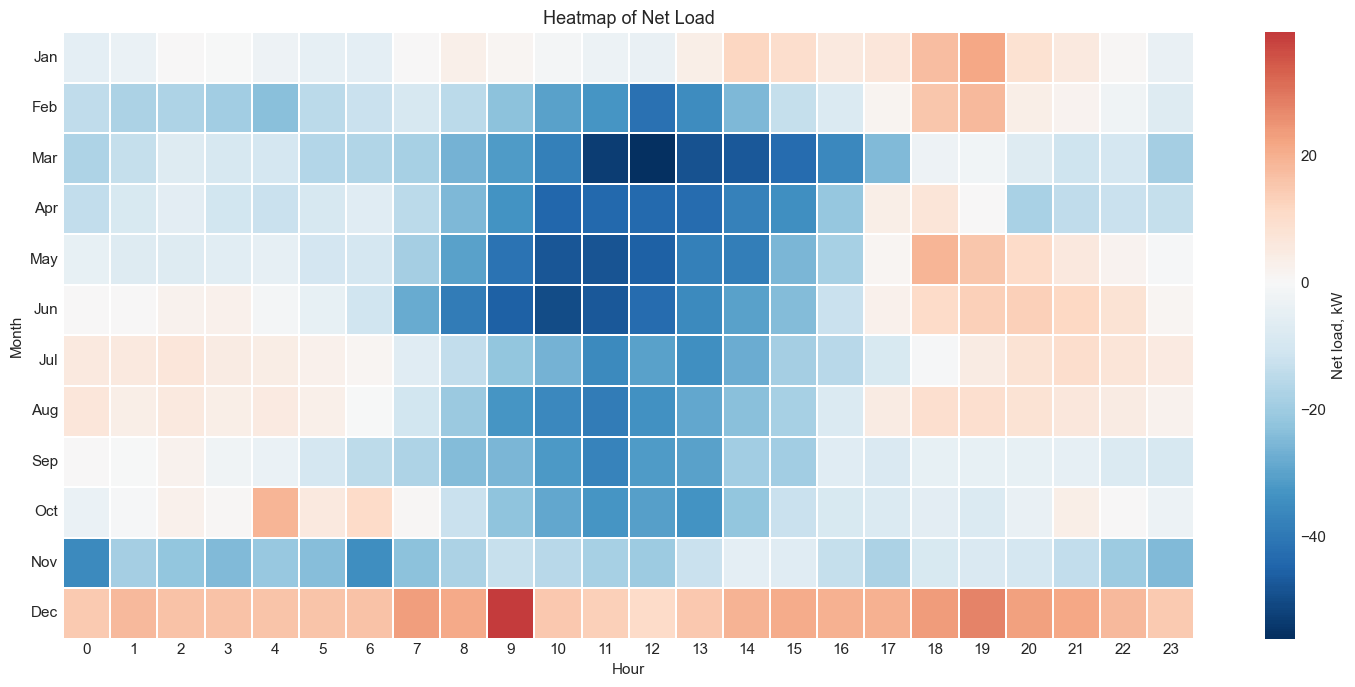

In [17]:
# ТЕПЛОВАЯ КАРТА NET LOAD

# СРЕДНЕЕ ЗНАЧЕНИЕ NET LOAD
# ДЛЯ КАЖДОГО ЧАСА И МЕСЯЦА

heatmap_data = df.pivot_table(

    values='net_load',
    index='month',
    columns='hour',
    aggfunc='mean'

)

# НАЗВАНИЯ МЕСЯЦЕВ

month_names = [

    'Jan', 'Feb', 'Mar', 'Apr',
    'May', 'Jun', 'Jul', 'Aug',
    'Sep', 'Oct', 'Nov', 'Dec'

]

# ПОСТРОЕНИЕ ТЕПЛОВОЙ КАРТЫ

fig, ax = plt.subplots(

    figsize=(15, 7)

)

sns.heatmap(

    heatmap_data,

    cmap='RdBu_r',

    center=0,

    linewidths=0.3,

    cbar_kws={
        'label': 'Net load, kW'
    },

    ax=ax

)

# ОФОРМЛЕНИЕ

ax.set_title(

    'Heatmap of Net Load'

)

ax.set_xlabel(

    'Hour'

)

ax.set_ylabel(

    'Month'

)

ax.set_yticklabels(

    month_names,
    rotation=0

)

plt.tight_layout()

plt.show()

# 5. Модель системы накопления энергии

В микросети используются два типа накопителей энергии:

1. Аккумуляторная батарея (Battery Energy Storage System, BESS)
2. Водородная система хранения энергии

Батарея используется для:
- сглаживания кратковременных колебаний нагрузки,
- компенсации пиков потребления,
- быстрого покрытия дефицита мощности.

Водородная система используется для:
- долгосрочного хранения избыточной энергии,
- покрытия продолжительных дефицитов генерации,
- повышения автономности микросети.

---

## 5.1 Принцип работы аккумуляторной батареи

При избытке генерации:
- батарея заряжается.

При дефиците энергии:
- батарея разряжается.

Состояние заряда батареи (State of Charge, SoC) изменяется в пределах допустимого диапазона.

Используются следующие ограничения:
- минимальный SoC,
- максимальный SoC,
- ограничение мощности заряда,
- ограничение мощности разряда.

## Заряд аккумулятора

$$
SOC_{t+1} =
SOC_t +
\frac{
P_{ch}\,\eta_{ch}\,\Delta t
}{
E_{bat}
}
$$

где:

- $SOC$ — уровень заряда батареи,
- $P_{ch}$ — мощность заряда,
- $\eta_{ch}$ — КПД заряда,
- $E_{bat}$ — емкость батареи.

---

## Разряд аккумулятора

$$
SOC_{t+1} =
SOC_t -
\frac{
P_{dis}\,\Delta t
}{
\eta_{dis}\,E_{bat}
}
$$

где:

- $P_{dis}$ — мощность разряда,
- $\eta_{dis}$ — КПД разряда.

---

## 5.2 Принцип работы водородной системы

Если батарея полностью заряжена и избыток энергии сохраняется:

- энергия направляется на электролизер,
- производится водород,
- водород сохраняется в хранилище.

При длительном дефиците энергии:

- водород поступает в топливный элемент,
- вырабатывается электрическая энергия,
- уменьшается потребление из внешней сети.

## Производство водорода

$$
H2_{t+1} =
H2_t +
\frac{
P_{el}\,\eta_{el}\,\Delta t
}{
E_{H2}
}
$$

где:

- $P_{el}$ — мощность электролизера,
- $\eta_{el}$ — КПД электролизера,
- $E_{H2}$ — емкость водородного хранилища.

---

## Использование водорода

$$
H2_{t+1} =
H2_t -
\frac{
P_{fc}\,\Delta t
}{
\eta_{fc}\,E_{H2}
}
$$

где:

- $P_{fc}$ — мощность топливного элемента,
- $\eta_{fc}$ — КПД топливного элемента.

In [18]:
# ПАРАМЕТРЫ АККУМУЛЯТОРНОЙ БАТАРЕИ

BATTERY_CAPACITY = 500          # кВт·ч

BATTERY_MAX_POWER = 400         # кВт

BATTERY_SOC_MIN = 0.20          # минимальный SoC

BATTERY_SOC_MAX = 0.90          # максимальный SoC

BATTERY_INITIAL_SOC = 0.50      # начальный SoC

BATTERY_ROUNDTRIP_EFF = 0.85    # КПД полного цикла

# КПД ЗАРЯДА И РАЗРЯДА

BATTERY_CHARGE_EFF = np.sqrt(

    BATTERY_ROUNDTRIP_EFF

)

BATTERY_DISCHARGE_EFF = np.sqrt(

    BATTERY_ROUNDTRIP_EFF

)

# ПАРАМЕТРЫ ВОДОРОДНОЙ СИСТЕМЫ

H2_CAPACITY = 1670              # кВт·ч

H2_INITIAL_LEVEL = 0.30         # начальный уровень заполнения

H2_ROUNDTRIP_EFF = 0.325        # полный КПД цикла

# ЭЛЕКТРОЛИЗЕР

MAX_ELECTROLYZER_POWER = 55     # кВт

# ТОПЛИВНЫЙ ЭЛЕМЕНТ

MAX_FUEL_CELL_POWER = 100       # кВт

# ------------------------------------------------------------
# КПД ВОДОРОДНОЙ СИСТЕМЫ
# ------------------------------------------------------------

ELECTROLYZER_EFF = np.sqrt(

    H2_ROUNDTRIP_EFF

)

FUEL_CELL_EFF = np.sqrt(

    H2_ROUNDTRIP_EFF

)

# ============================================================
# ВЫВОД ПАРАМЕТРОВ
# ============================================================

print('BATTERY PARAMETERS')
print('--------------------------')

print(f'Capacity: {BATTERY_CAPACITY} kWh')
print(f'Max power: {BATTERY_MAX_POWER} kW')
print(f'SoC range: {BATTERY_SOC_MIN:.0%} - {BATTERY_SOC_MAX:.0%}')
print(f'Round-trip efficiency: {BATTERY_ROUNDTRIP_EFF:.0%}')

print()

print('HYDROGEN SYSTEM PARAMETERS')
print('--------------------------')

print(f'H2 capacity: {H2_CAPACITY} kWh')
print(f'Electrolyzer power: {MAX_ELECTROLYZER_POWER} kW')
print(f'Fuel cell power: {MAX_FUEL_CELL_POWER} kW')
print(f'Round-trip efficiency: {H2_ROUNDTRIP_EFF:.1%}')

BATTERY PARAMETERS
--------------------------
Capacity: 500 kWh
Max power: 400 kW
SoC range: 20% - 90%
Round-trip efficiency: 85%

HYDROGEN SYSTEM PARAMETERS
--------------------------
H2 capacity: 1670 kWh
Electrolyzer power: 55 kW
Fuel cell power: 100 kW
Round-trip efficiency: 32.5%


# 6. Стратегии управления накопителями энергии

В работе рассматриваются несколько стратегий управления накопителями энергии.

Основная цель:
- минимизация потребления энергии из внешней сети,
- снижение стоимости электроэнергии,
- сглаживание пиков нагрузки.

Сравнение стратегий позволяет определить наиболее эффективный алгоритм управления микросетью.

---

## 6.1 Стратегия Always

Стратегия `Always` является базовой.

Принцип работы:

- при избытке генерации накопители всегда заряжаются,
- при дефиците энергии накопители всегда разряжаются.

Последовательность работы:
1. сначала используется аккумуляторная батарея,
2. затем водородная система,
3. остаточный дефицит покрывается из внешней сети.

Преимущество:
- минимизация импорта электроэнергии.

Недостаток:
- большое количество циклов зарядки и разрядки батареи.

---

## 6.2 Стратегия Peak Shaving

Стратегия `Peak Shaving` предназначена для ограничения пиков нагрузки.

Батарея начинает разряжаться только тогда, когда:

$$
P_{net} > P_{threshold}
$$

где:
- $P_{threshold}$ — заданный порог мощности.

В работе рассматриваются несколько уровней:
- 50 кВт,
- 100 кВт,
- 150 кВт,
- 200 кВт.

Преимущество:
- снижение максимальной нагрузки на сеть;
- уменьшение пиковых тарифов.

Недостаток:
- увеличение потребления энергии из сети по сравнению со стратегией Always.

---

## 6.3 Стратегия Time-of-Day (TOD)

Стратегия `TOD` использует особенности суточного профиля нагрузки.

Алгоритм:
- заряд батареи выполняется при избытке генерации независимо от времени суток,
- разряд батареи выполняется только в часы максимального net load.

На основе анализа профиля нагрузки выбираются часы:
- утреннего пика;
- вечернего пика.

Преимущество:
- более рациональное использование накопителей,
- снижение износа батареи.

---

## 6.4 Логика работы водородной системы

Водородная система используется во всех стратегиях.

Алгоритм работы:

### При избытке энергии:
1. сначала заряжается батарея,
2. затем энергия направляется в электролизер,
3. производится водород.

### При дефиците энергии:
1. сначала используется батарея,
2. затем топливный элемент,
3. остаток энергии покупается из сети.

Таким образом:
- батарея компенсирует кратковременные колебания;
- водородная система покрывает длительные дефициты энергии.

HIGH LOAD HOURS
[19, 18, 20, 21, 22, 17]


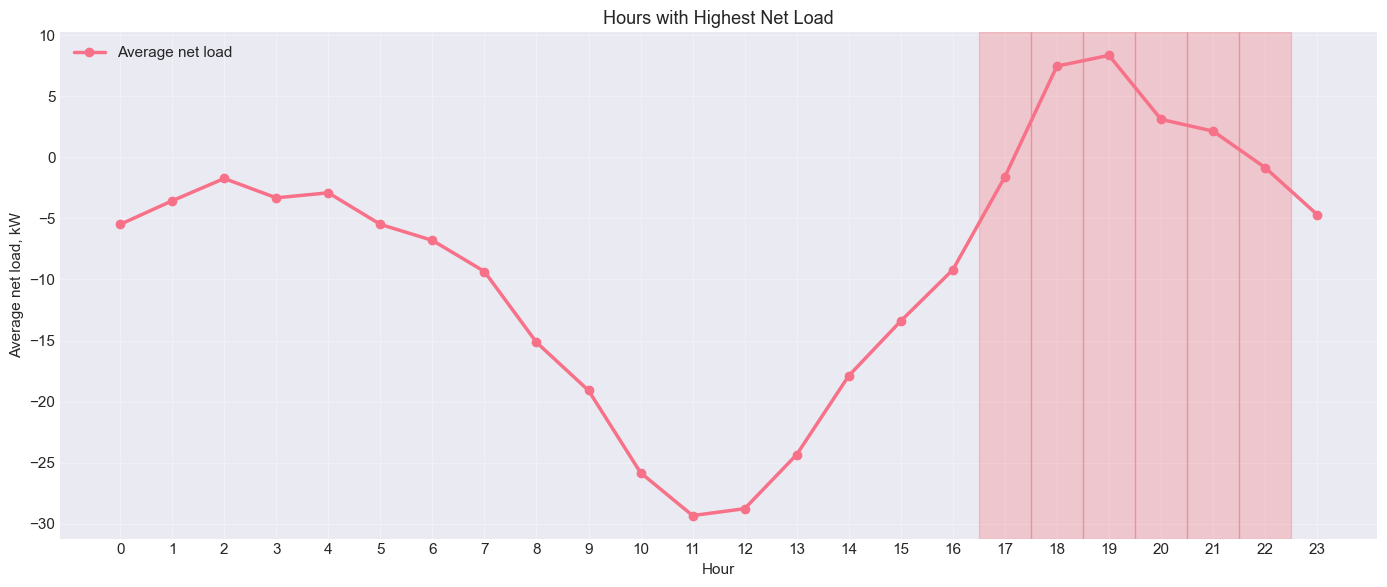

In [19]:
# ЧАСЫ ПОВЫШЕННОЙ НАГРУЗКИ
# ДЛЯ СТРАТЕГИИ TOD

# СРЕДНИЙ NET LOAD ПО ЧАСАМ

hourly_net_load = (

    df.groupby('hour')['net_load']
    .mean()

)

# ВЫБОР ЧАСОВ
# С НАИБОЛЬШЕЙ НАГРУЗКОЙ

high_load_hours = (

    hourly_net_load
    .sort_values(ascending=False)
    .head(6)
    .index
    .tolist()

)

print('HIGH LOAD HOURS')

print(high_load_hours)

# ВИЗУАЛИЗАЦИЯ СУТОЧНОГО ПРОФИЛЯ

fig, ax = plt.subplots(

    figsize=(14, 6)

)

# СРЕДНИЙ NET LOAD

ax.plot(

    hourly_net_load.index,
    hourly_net_load.values,

    linewidth=2.5,
    marker='o',
    label='Average net load'

)

# ВЫДЕЛЕНИЕ ЧАСОВ
# ДЛЯ РАЗРЯДА БАТАРЕИ

for hour in high_load_hours:

    ax.axvspan(

        hour - 0.5,
        hour + 0.5,

        color='red',
        alpha=0.15

    )

# ОФОРМЛЕНИЕ

ax.set_title(

    'Hours with Highest Net Load'

)

ax.set_xlabel(

    'Hour'

)

ax.set_ylabel(

    'Average net load, kW'

)

ax.set_xticks(range(24))

ax.grid(True, alpha=0.3)

ax.legend()

plt.tight_layout()

plt.show()

# 7. Реализация математической модели накопителей

Для моделирования работы микросети реализуются отдельные функции:

1. зарядки водородного хранилища,
2. разрядки водородного хранилища,
3. симуляции работы накопителей по выбранной стратегии.

---

## 7.1 Зарядка водородного хранилища

При наличии избытка энергии:
- энергия направляется в электролизер,
- производится водород,
- уровень заполнения хранилища увеличивается.

Ограничения:
- максимальная мощность электролизера,
- максимальная емкость хранилища.

---

## 7.2 Разрядка водородного хранилища

При дефиците энергии:
- используется топливный элемент,
- водород преобразуется обратно в электрическую энергию.

Ограничения:
- максимальная мощность топливного элемента,
- текущий запас водорода.

---

## 7.3 Логика моделирования

На каждом временном шаге выполняются:
1. расчет net load,
2. принятие решения по стратегии,
3. заряд/разряд батареи,
4. работа водородной системы,
5. расчет импорта энергии из сети.

Дополнительно сохраняются:
- состояние заряда батареи,
- уровень водорода,
- мощность батареи,
- мощность электролизера,
- мощность топливного элемента,
- импорт энергии из сети.

In [20]:
# ФУНКЦИЯ ЗАРЯДКИ ВОДОРОДНОГО ХРАНИЛИЩА

def hydrogen_charge(

    surplus_power,
    h2_level

):

    # МОЩНОСТЬ ЭЛЕКТРОЛИЗЕРА

    electrolyzer_power = 0

    # ПРОВЕРКА НАЛИЧИЯ ИЗБЫТКА ЭНЕРГИИ

    if surplus_power > 0 and h2_level < 1.0:

        # ОГРАНИЧЕНИЕ ПО МОЩНОСТИ

        electrolyzer_power = min(

            surplus_power,
            MAX_ELECTROLYZER_POWER

        )

        # ДОСТУПНОЕ МЕСТО В ХРАНИЛИЩЕ

        available_capacity = (

            (1.0 - h2_level)
            * H2_CAPACITY
            / ELECTROLYZER_EFF

        )

        electrolyzer_power = min(

            electrolyzer_power,
            available_capacity

        )

        # ОБНОВЛЕНИЕ УРОВНЯ ВОДОРОДА

        h2_level += (

            electrolyzer_power
            * ELECTROLYZER_EFF
            / H2_CAPACITY

        )

    return electrolyzer_power, h2_level


# ФУНКЦИЯ РАЗРЯДКИ ВОДОРОДНОГО ХРАНИЛИЩА

def hydrogen_discharge(

    deficit_power,
    h2_level

):

    # МОЩНОСТЬ ТОПЛИВНОГО ЭЛЕМЕНТА

    fuel_cell_power = 0

    # ПРОВЕРКА НАЛИЧИЯ ДЕФИЦИТА

    if deficit_power > 0 and h2_level > 0:

        # ДОСТУПНАЯ ЭНЕРГИЯ ВОДОРОДА

        available_h2_energy = (

            h2_level
            * H2_CAPACITY
            * FUEL_CELL_EFF

        )

        # ОГРАНИЧЕНИЕ МОЩНОСТИ

        fuel_cell_power = min(

            deficit_power,
            MAX_FUEL_CELL_POWER,
            available_h2_energy

        )

        # ОБНОВЛЕНИЕ УРОВНЯ ВОДОРОДА

        h2_level -= (

            fuel_cell_power
            / (FUEL_CELL_EFF * H2_CAPACITY)

        )

        # ОБНОВЛЕНИЕ ДЕФИЦИТА

        deficit_power -= fuel_cell_power

    return fuel_cell_power, h2_level, deficit_power

# 8. Моделирование стратегий управления накопителями

В работе рассматриваются три стратегии управления накопителями энергии:

1. Always  
   Накопители всегда участвуют в покрытии дефицита и поглощении избытка энергии.

2. Peak Shaving  
   Батарея используется только для ограничения пиков net load.

3. Time-of-Day (TOD)  
   Использование батареи зависит от времени суток и характерных часов высокой нагрузки.

Во всех стратегиях:
- батарея имеет приоритет при краткосрочном балансировании,
- водород используется как долгосрочное хранилище,
- остаточный дефицит покрывается внешней сетью.

In [21]:
# ФУНКЦИЯ МОДЕЛИРОВАНИЯ СТРАТЕГИЙ УПРАВЛЕНИЯ


def simulate_strategy(

    data,
    strategy='always',
    peak_threshold=None

):

   
    # КОПИЯ ИСХОДНЫХ ДАННЫХ
    

    sim = data.copy()

    
    # НАЧАЛЬНЫЕ СОСТОЯНИЯ СИСТЕМЫ
    

    battery_soc = BATTERY_INITIAL_SOC

    h2_level = H2_INITIAL_LEVEL

    
    # МАССИВЫ ДЛЯ СОХРАНЕНИЯ РЕЗУЛЬТАТОВ
    

    battery_soc_history = []

    h2_history = []

    battery_power_history = []

    electrolyzer_history = []

    fuel_cell_history = []

    grid_import_history = []

    
    # ПОДГОТОВКА TOD СТРАТЕГИИ
    

    if strategy == 'tod':

        hourly_profile = (

            sim.groupby('hour')['net_load']
            .mean()

        )

        peak_hours = (

            hourly_profile
            .sort_values(ascending=False)
            .head(6)
            .index
            .tolist()

        )

    
    # ОСНОВНОЙ ЦИКЛ МОДЕЛИРОВАНИЯ
    

    for _, row in sim.iterrows():

        net_load = row['net_load']

        hour = row['hour']

        
        # ПЕРЕМЕННЫЕ ТЕКУЩЕГО ШАГА
        

        battery_power = 0.0

        electrolyzer_power = 0.0

        fuel_cell_power = 0.0

        grid_import = 0.0

        
        # STRATEGY: ALWAYS
        

        if strategy == 'always':

           
            # ИЗБЫТОК ЭНЕРГИИ
            

            if net_load < 0:

                surplus = -net_load

                battery_space = (

                    (BATTERY_SOC_MAX - battery_soc)
                    * BATTERY_CAPACITY

                )

                battery_charge = min(

                    surplus,
                    BATTERY_MAX_POWER,
                    battery_space

                )

                if battery_charge > 0:

                    battery_soc += (

                        battery_charge
                        * BATTERY_CHARGE_EFF
                        / BATTERY_CAPACITY

                    )

                    battery_power = -battery_charge

                    surplus -= battery_charge

                # ВОДОРОД

                if surplus > 0:

                    electrolyzer_power, h2_level = hydrogen_charge(

                        surplus,
                        h2_level

                    )

            
            # ДЕФИЦИТ ЭНЕРГИИ
            

            else:

                deficit = net_load

                available_energy = (

                    (battery_soc - BATTERY_SOC_MIN)
                    * BATTERY_CAPACITY

                )

                battery_discharge = min(

                    deficit,
                    BATTERY_MAX_POWER,
                    available_energy

                )

                if battery_discharge > 0:

                    battery_soc -= (

                        battery_discharge
                        / BATTERY_DISCHARGE_EFF
                        / BATTERY_CAPACITY

                    )

                    battery_power = battery_discharge

                    deficit -= battery_discharge

                # ВОДОРОД

                if deficit > 0:

                    fuel_cell_power, h2_level, deficit = hydrogen_discharge(

                        deficit,
                        h2_level

                    )

                # СЕТЬ

                if deficit > 0:

                    grid_import = deficit

        
        # STRATEGY: PEAK SHAVING
        

        elif strategy == 'peak':

            
            # ИЗБЫТОК ЭНЕРГИИ
            

            if net_load < 0:

                surplus = -net_load

                battery_space = (

                    (BATTERY_SOC_MAX - battery_soc)
                    * BATTERY_CAPACITY

                )

                battery_charge = min(

                    surplus,
                    BATTERY_MAX_POWER,
                    battery_space

                )

                if battery_charge > 0:

                    battery_soc += (

                        battery_charge
                        * BATTERY_CHARGE_EFF
                        / BATTERY_CAPACITY

                    )

                    battery_power = -battery_charge

                    surplus -= battery_charge

                # ВОДОРОД

                if surplus > 0:

                    electrolyzer_power, h2_level = hydrogen_charge(

                        surplus,
                        h2_level

                    )

            
            # ДЕФИЦИТ ЭНЕРГИИ
            

            else:

                deficit = net_load

                
                # СГЛАЖИВАНИЕ ПИКОВ
                

                if deficit > peak_threshold:

                    peak_excess = (

                        deficit
                        - peak_threshold

                    )

                    available_energy = (

                        (battery_soc - BATTERY_SOC_MIN)
                        * BATTERY_CAPACITY

                    )

                    battery_discharge = min(

                        peak_excess,
                        BATTERY_MAX_POWER,
                        available_energy

                    )

                    if battery_discharge > 0:

                        battery_soc -= (

                            battery_discharge
                            / BATTERY_DISCHARGE_EFF
                            / BATTERY_CAPACITY

                        )

                        battery_power = battery_discharge

                        deficit -= battery_discharge

                
                # ВОДОРОДНОЕ ХРАНИЛИЩЕ
                

                if deficit > 0:

                    fuel_cell_power, h2_level, deficit = hydrogen_discharge(

                        deficit,
                        h2_level

                    )

                
                # ИМПОРТ ИЗ СЕТИ
                

                if deficit > 0:

                    grid_import = deficit

        
        # STRATEGY: TOD
        

        elif strategy == 'tod':

            
            # ИЗБЫТОК ЭНЕРГИИ
            

            if net_load < 0:

                surplus = -net_load

                battery_space = (

                    (BATTERY_SOC_MAX - battery_soc)
                    * BATTERY_CAPACITY

                )

                battery_charge = min(

                    surplus,
                    BATTERY_MAX_POWER,
                    battery_space

                )

                if battery_charge > 0:

                    battery_soc += (

                        battery_charge
                        * BATTERY_CHARGE_EFF
                        / BATTERY_CAPACITY

                    )

                    battery_power = -battery_charge

                    surplus -= battery_charge

                # ВОДОРОД

                if surplus > 0:

                    electrolyzer_power, h2_level = hydrogen_charge(

                        surplus,
                        h2_level

                    )

            
            # ДЕФИЦИТ ЭНЕРГИИ
            

            else:

                deficit = net_load

                
                # РАЗРЯД ТОЛЬКО В ПИКОВЫЕ ЧАСЫ
                

                if hour in peak_hours:

                    available_energy = (

                        (battery_soc - BATTERY_SOC_MIN)
                        * BATTERY_CAPACITY

                    )

                    battery_discharge = min(

                        deficit,
                        BATTERY_MAX_POWER,
                        available_energy

                    )

                    if battery_discharge > 0:

                        battery_soc -= (

                            battery_discharge
                            / BATTERY_DISCHARGE_EFF
                            / BATTERY_CAPACITY

                        )

                        battery_power = battery_discharge

                        deficit -= battery_discharge

                # ВОДОРОД

                if deficit > 0:

                    fuel_cell_power, h2_level, deficit = hydrogen_discharge(

                        deficit,
                        h2_level

                    )

                # СЕТЬ

                if deficit > 0:

                    grid_import = deficit

        
        # ОГРАНИЧЕНИЯ СОСТОЯНИЯ
        

        battery_soc = np.clip(

            battery_soc,
            BATTERY_SOC_MIN,
            BATTERY_SOC_MAX

        )

        h2_level = np.clip(

            h2_level,
            0.0,
            1.0

        )

        
        # СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
        

        battery_soc_history.append(battery_soc)

        h2_history.append(h2_level)

        battery_power_history.append(battery_power)

        electrolyzer_history.append(electrolyzer_power)

        fuel_cell_history.append(fuel_cell_power)

        grid_import_history.append(grid_import)

    
    # СОХРАНЕНИЕ В DATAFRAME
    

    sim['battery_soc'] = battery_soc_history

    sim['h2_level'] = h2_history

    sim['battery_power'] = battery_power_history

    sim['electrolyzer_power'] = electrolyzer_history

    sim['fuel_cell_power'] = fuel_cell_history

    sim['grid_import'] = grid_import_history

    
    # СТОИМОСТЬ ЭНЕРГИИ
    

    sim['energy_cost'] = (

        sim['grid_import']
        * df['energy_cost_NOK']

    )

    
    # ПИКОВАЯ МОЩНОСТЬ
    

    sim['year_month'] = (

        sim['timestamp']
        .dt
        .to_period('M')

    )

    monthly_peak = (

        sim.groupby('year_month')['grid_import']
        .max()

    )

    sim['peak_cost'] = 0.0

    for month, peak_value in monthly_peak.items():

        month_mask = (

            sim['year_month']
            == month

        )

        month_length = month_mask.sum()

        sim.loc[month_mask, 'peak_cost'] = (

            peak_value
            * PEAK_TARIFF
            / month_length

        )

    
    # ОБЩАЯ СТОИМОСТЬ
    

    sim['total_cost'] = (

        sim['energy_cost']
        + sim['peak_cost']

    )

    return sim

# 9. Запуск моделирования для разных стратегий

На данном этапе выполняется моделирование работы микросети для нескольких алгоритмов управления накопителями энергии.

Рассматриваются:

- стратегия Always,
- несколько вариантов Peak Shaving,
- стратегия Time-of-Day.

Для Peak Shaving используются разные значения пороговой мощности, что позволяет оценить влияние глубины сглаживания пиков на:
- импорт электроэнергии из сети,
- нагрузку на АКБ,
- использование водородной системы,
- общую стоимость электроэнергии.

In [22]:
# СЛОВАРЬ ДЛЯ ХРАНЕНИЯ РЕЗУЛЬТАТОВ


strategies = {}


# ALWAYS


print('Running Always strategy...')

strategies['Always'] = simulate_strategy(

    df,
    strategy='always'

)

print('Always completed')


# PEAK SHAVING


peak_thresholds = [

    5,
    10,
    20,
    30,
    40

]

for threshold in peak_thresholds:

    strategy_name = f'Peak_{threshold}'

    print(f'Running {strategy_name}...')

    strategies[strategy_name] = simulate_strategy(

        df,
        strategy='peak',
        peak_threshold=threshold

    )

    print(f'{strategy_name} completed')


# TIME OF DAY


print('Running TOD strategy...')

strategies['TOD'] = simulate_strategy(

    df,
    strategy='tod'

)

print('TOD completed')


# ПРОВЕРКА


print()

print('AVAILABLE STRATEGIES:')

for key in strategies.keys():

    print('-', key)

Running Always strategy...
Always completed
Running Peak_5...
Peak_5 completed
Running Peak_10...
Peak_10 completed
Running Peak_20...
Peak_20 completed
Running Peak_30...
Peak_30 completed
Running Peak_40...
Peak_40 completed
Running TOD strategy...
TOD completed

AVAILABLE STRATEGIES:
- Always
- Peak_5
- Peak_10
- Peak_20
- Peak_30
- Peak_40
- TOD


# 10. Сравнение стратегий управления

На данном этапе выполняется количественное сравнение всех реализованных стратегий управления накопителями энергии.

Для каждой стратегии рассчитываются:

- объем электроэнергии, импортированной из внешней сети,
- стоимость потребленной электроэнергии,
- стоимость пикового потребления мощности,
- суммарные эксплуатационные затраты,
- средняя стоимость 1 кВт·ч импортированной энергии.

Сравнение позволяет определить наиболее эффективный алгоритм управления гибридной системой накопления энергии.

Стоимость покупки энергии из сети определяется как:

$$
C_{energy} =
\sum_t
P_{grid}(t)\,
Price(t)
$$

где:

- $P_{grid}$ — импорт мощности из сети,
- $Price(t)$ — почасовая цена электроэнергии.

---

# Стоимость пиковой мощности

Плата за пиковое потребление определяется как:

$$
C_{peak} =
P_{peak}^{month}
\cdot
Tariff_{peak}
$$

где:

$$
P_{peak}^{month}
=
\max(P_{grid})
$$

— максимальная мощность импорта за месяц.

---

# Общая стоимость системы

Итоговая стоимость:

$$
C_{total} =
C_{energy}
+
C_{peak}
$$

In [23]:
# ТАБЛИЦА РЕЗУЛЬТАТОВ


results = []


# ОБХОД ВСЕХ СТРАТЕГИЙ


for strategy_name, sim in strategies.items():

    
    # ИМПОРТ ЭНЕРГИИ ИЗ СЕТИ
    

    total_grid_import = sim['grid_import'].sum()

   
    # ЭНЕРГЕТИЧЕСКАЯ СОСТАВЛЯЮЩАЯ
    

    total_energy_cost = sim['energy_cost'].sum()

    
    # ПИКОВАЯ СОСТАВЛЯЮЩАЯ
    

    total_peak_cost = sim['peak_cost'].sum()

    
    # ОБЩАЯ СТОИМОСТЬ
    

    total_cost = sim['total_cost'].sum()

    
    # СРЕДНЯЯ ЦЕНА ИМПОРТА
    

    if total_grid_import > 0:

        average_price = (

            total_cost
            / total_grid_import

        )

    else:

        average_price = 0

    
    # СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
    

    results.append({

        'Strategy': strategy_name,

        'Grid import (kWh)': total_grid_import,

        'Energy cost (NOK)': total_energy_cost,

        'Peak cost (NOK)': total_peak_cost,

        'Total cost (NOK)': total_cost,

        'Average import price (NOK/kWh)': average_price

    })


# DATAFRAME С РЕЗУЛЬТАТАМИ


results_df = pd.DataFrame(results)


# СОРТИРОВКА ПО ОБЩЕЙ СТОИМОСТИ


results_df = results_df.sort_values(

    by='Total cost (NOK)'

).reset_index(drop=True)


# ВЫВОД ТАБЛИЦЫ


print(results_df)

  Strategy  Grid import (kWh)  Energy cost (NOK)  Peak cost (NOK)  \
0  Peak_30       51226.002707       13798.802562     34923.983159   
1  Peak_40       52134.202376       13978.599510     37759.770982   
2   Always       36259.583051       11196.155180     47764.142360   
3  Peak_20       47700.458754       13070.832629     47898.960102   
4  Peak_10       40072.590809       11795.660665     50001.052521   
5   Peak_5       37320.810817       11392.926523     50441.770833   
6      TOD       40105.370360       11891.929584     70495.832449   

   Total cost (NOK)  Average import price (NOK/kWh)  
0      48722.785721                        0.951134  
1      51738.370492                        0.992407  
2      58960.297540                        1.626061  
3      60969.792731                        1.278180  
4      61796.713186                        1.542119  
5      61834.697356                        1.656842  
6      82387.762033                        2.054283  


# 11. Визуальное сравнение стратегий

После выполнения численного сравнения необходимо провести визуальный анализ результатов моделирования.

На графиках ниже сравниваются:

- суммарные затраты для различных стратегий;
- объем импортируемой энергии из сети;
- вклад энергетической и пиковой составляющей тарифа;
- средняя стоимость импортируемой энергии.

Такой анализ позволяет оценить эффективность каждой стратегии не только по одному критерию, но и по структуре затрат.

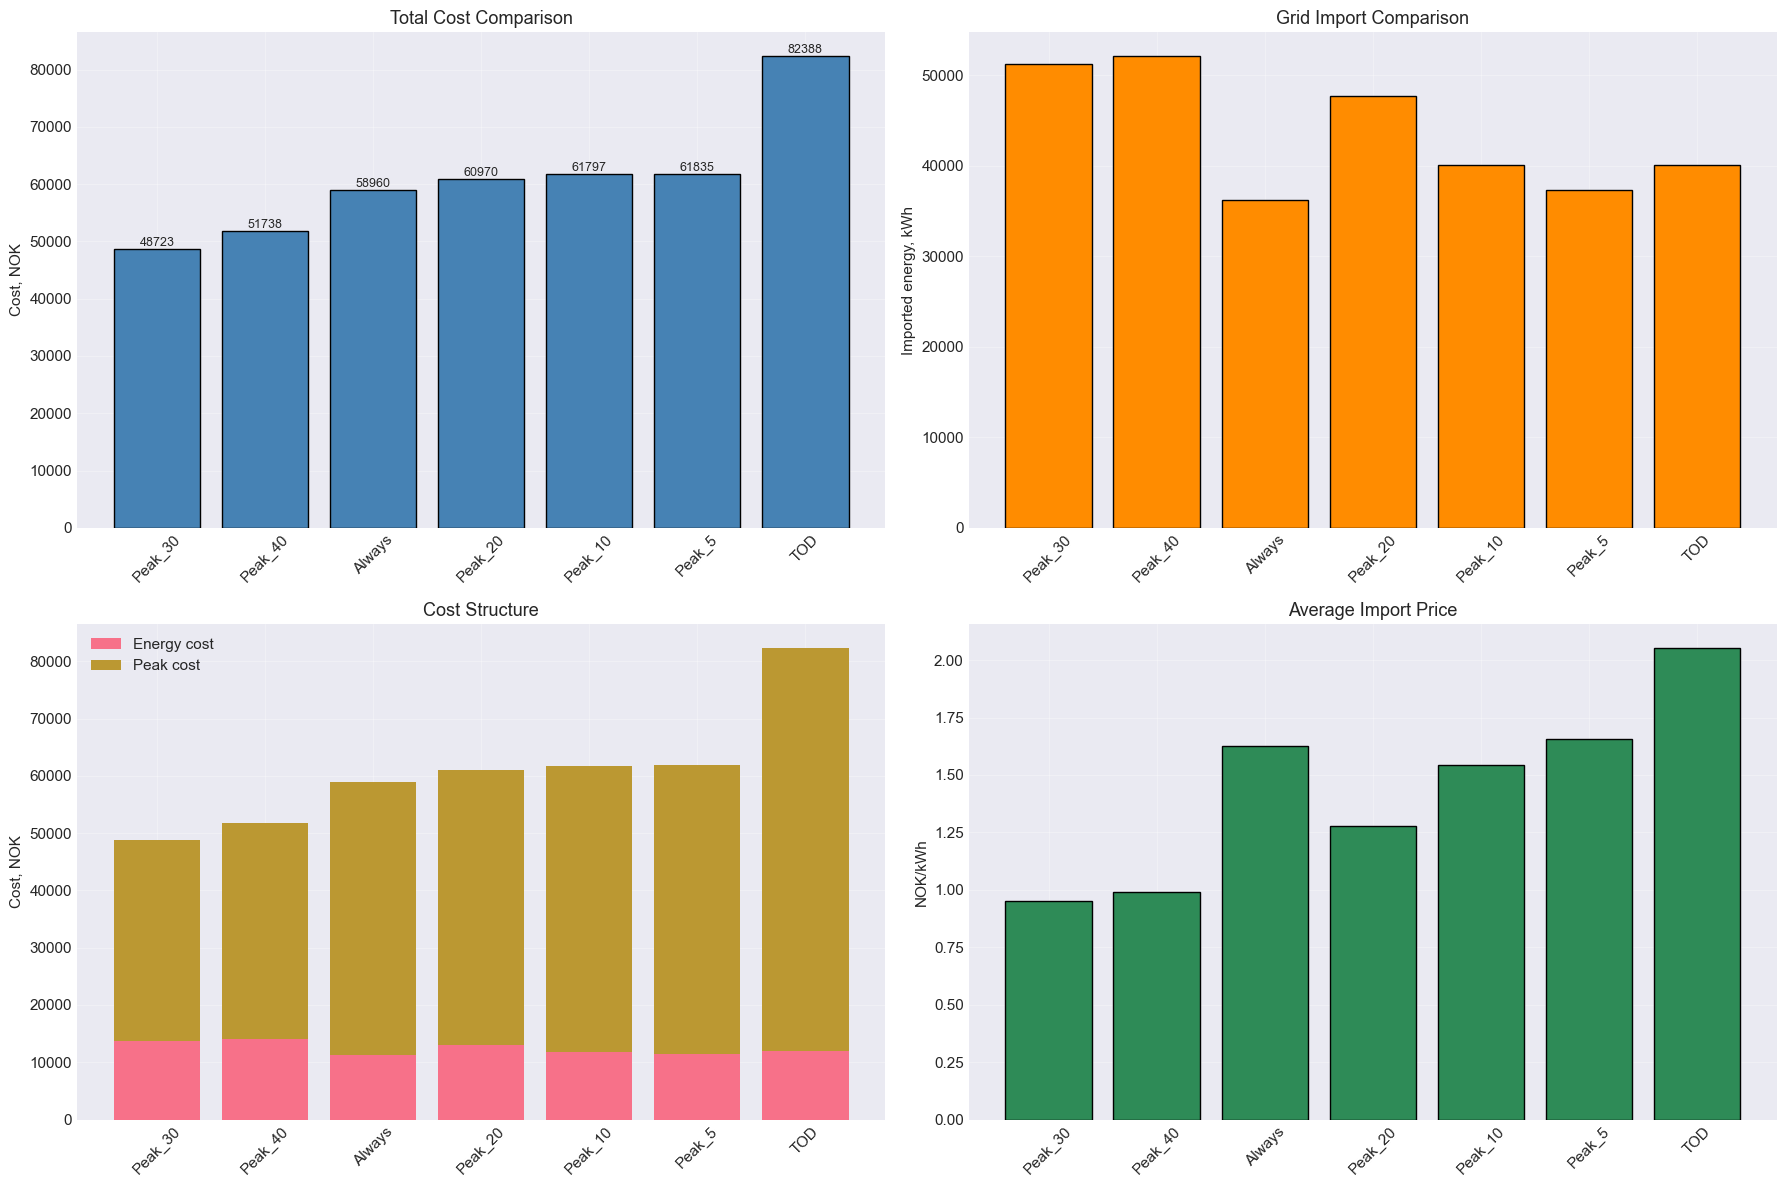

In [24]:
# ГРАФИКИ СРАВНЕНИЯ СТРАТЕГИЙ


fig, axes = plt.subplots(

    2, 2,
    figsize=(18, 12)

)


# 1. ОБЩАЯ СТОИМОСТЬ


ax = axes[0, 0]

bars = ax.bar(

    results_df['Strategy'],
    results_df['Total cost (NOK)'],

    color='steelblue',
    edgecolor='black'

)

ax.set_title(

    'Total Cost Comparison'

)

ax.set_ylabel(

    'Cost, NOK'

)

ax.grid(

    True,
    alpha=0.3

)

plt.setp(

    ax.get_xticklabels(),
    rotation=45

)

# ПОДПИСИ НА СТОЛБЦАХ

for bar in bars:

    value = bar.get_height()

    ax.text(

        bar.get_x() + bar.get_width()/2,
        value,

        f'{value:.0f}',

        ha='center',
        va='bottom',
        fontsize=9

    )


# 2. ИМПОРТ ИЗ СЕТИ


ax = axes[0, 1]

bars = ax.bar(

    results_df['Strategy'],
    results_df['Grid import (kWh)'],

    color='darkorange',
    edgecolor='black'

)

ax.set_title(

    'Grid Import Comparison'

)

ax.set_ylabel(

    'Imported energy, kWh'

)

ax.grid(

    True,
    alpha=0.3

)

plt.setp(

    ax.get_xticklabels(),
    rotation=45

)


# 3. СТРУКТУРА ЗАТРАТ


ax = axes[1, 0]

x = np.arange(

    len(results_df)

)

ax.bar(

    x,
    results_df['Energy cost (NOK)'],

    label='Energy cost'

)

ax.bar(

    x,
    results_df['Peak cost (NOK)'],

    bottom=results_df['Energy cost (NOK)'],

    label='Peak cost'

)

ax.set_xticks(

    x

)

ax.set_xticklabels(

    results_df['Strategy'],
    rotation=45

)

ax.set_title(

    'Cost Structure'

)

ax.set_ylabel(

    'Cost, NOK'

)

ax.legend()

ax.grid(

    True,
    alpha=0.3

)


# 4. СРЕДНЯЯ СТОИМОСТЬ ИМПОРТА


ax = axes[1, 1]

bars = ax.bar(

    results_df['Strategy'],
    results_df['Average import price (NOK/kWh)'],

    color='seagreen',
    edgecolor='black'

)

ax.set_title(

    'Average Import Price'

)

ax.set_ylabel(

    'NOK/kWh'

)

ax.grid(

    True,
    alpha=0.3

)

plt.setp(

    ax.get_xticklabels(),
    rotation=45

)


# ОБЩЕЕ ОФОРМЛЕНИЕ


plt.tight_layout()

plt.show()

# 12. Анализ состояния заряда аккумуляторной батареи

Состояние заряда аккумуляторной батареи (State of Charge, SoC) является одним из ключевых параметров при анализе эффективности стратегии управления накопителями.

Графики ниже позволяют оценить:
- глубину циклирования батареи,
- частоту зарядки и разрядки,
- использование доступного диапазона SoC,
- различия между стратегиями управления.

Для анализа выбраны:
- зимняя неделя с выраженным дефицитом генерации,
- летняя неделя с высоким уровнем солнечной генерации.

Дополнительно отображаются:
- минимально допустимый уровень заряда,
- максимально допустимый уровень заряда.

Это позволяет проверить корректность работы ограничений модели накопителя.

In [25]:
# ВРЕМЕННЫЕ ИНТЕРВАЛЫ ДЛЯ АНАЛИЗА


winter_period = (

    (df['timestamp'] >= '2020-01-06')
    &
    (df['timestamp'] < '2020-01-13')

)

summer_period = (

    (df['timestamp'] >= '2020-07-06')
    &
    (df['timestamp'] < '2020-07-13')

)

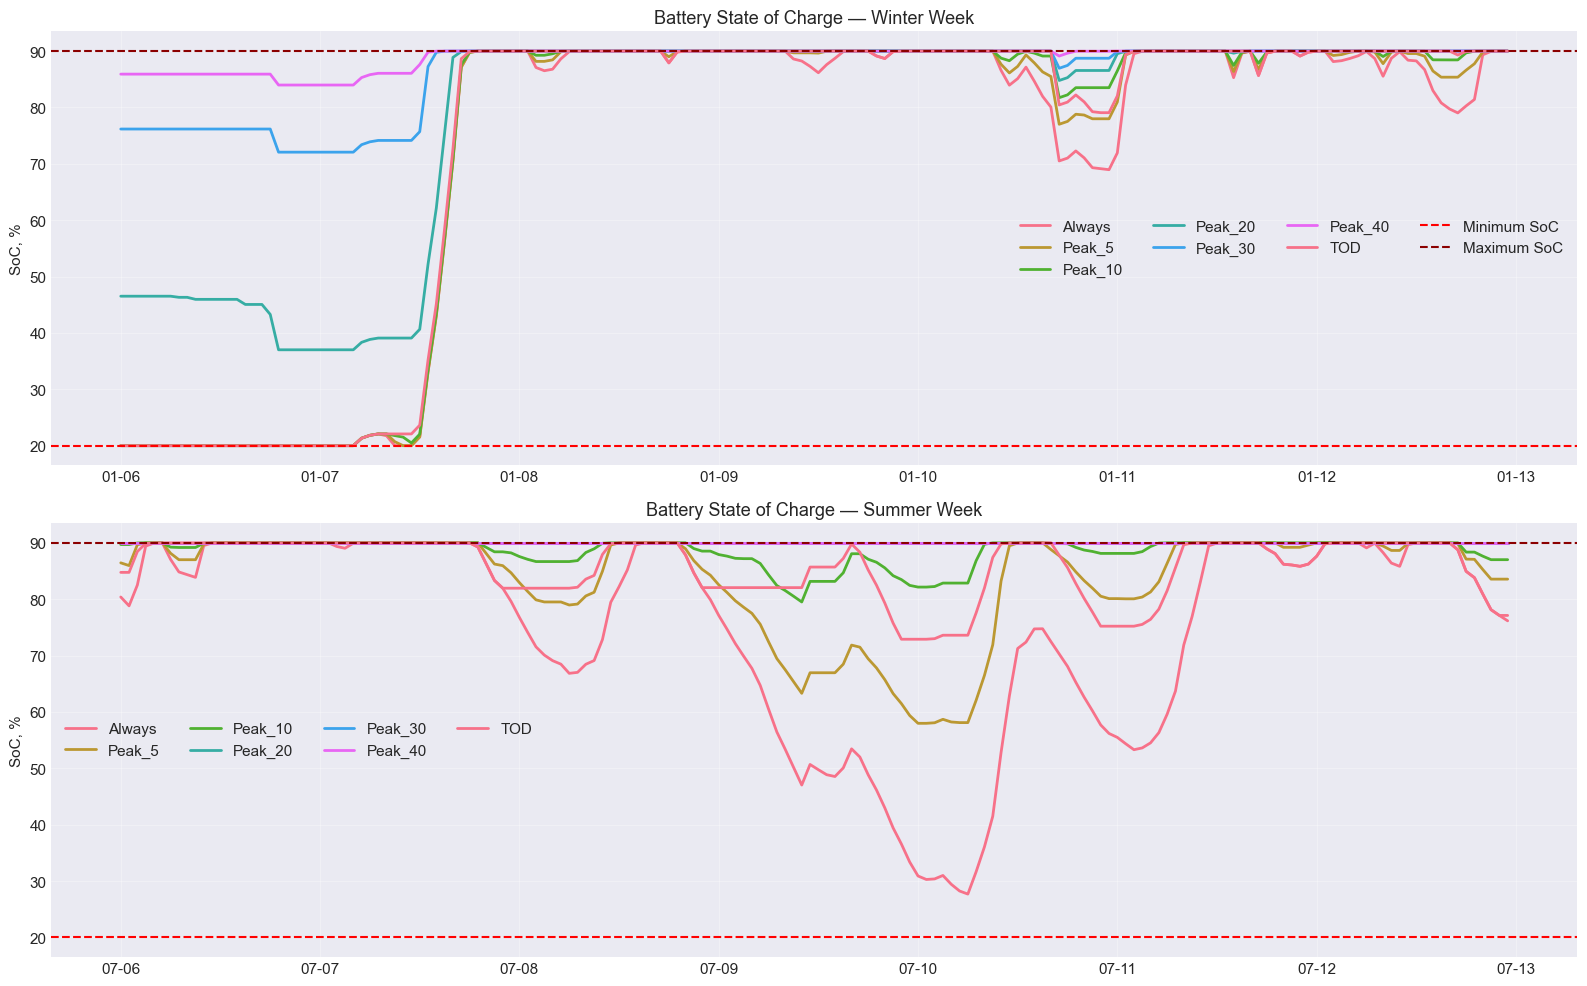

In [26]:
# ГРАФИКИ СОСТОЯНИЯ ЗАРЯДА БАТАРЕИ


fig, axes = plt.subplots(

    2, 1,
    figsize=(16, 10)

)


# ЗИМНИЙ ПЕРИОД


ax = axes[0]

for strategy_name in strategies.keys():

    sim = strategies[strategy_name]

    ax.plot(

        sim.loc[winter_period, 'timestamp'],
        sim.loc[winter_period, 'battery_soc'] * 100,

        linewidth=2,
        label=strategy_name

    )

# МИНИМАЛЬНЫЙ SoC

ax.axhline(

    BATTERY_SOC_MIN * 100,

    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Minimum SoC'

)

# МАКСИМАЛЬНЫЙ SoC

ax.axhline(

    BATTERY_SOC_MAX * 100,

    color='darkred',
    linestyle='--',
    linewidth=1.5,
    label='Maximum SoC'

)

ax.set_title(

    'Battery State of Charge — Winter Week'

)

ax.set_ylabel(

    'SoC, %'

)

ax.legend(

    ncol=4

)

ax.grid(

    True,
    alpha=0.3

)

ax.xaxis.set_major_formatter(

    DateFormatter('%m-%d')

)


# ЛЕТНИЙ ПЕРИОД


ax = axes[1]

for strategy_name in strategies.keys():

    sim = strategies[strategy_name]

    ax.plot(

        sim.loc[summer_period, 'timestamp'],
        sim.loc[summer_period, 'battery_soc'] * 100,

        linewidth=2,
        label=strategy_name

    )

ax.axhline(

    BATTERY_SOC_MIN * 100,

    color='red',
    linestyle='--',
    linewidth=1.5

)

ax.axhline(

    BATTERY_SOC_MAX * 100,

    color='darkred',
    linestyle='--',
    linewidth=1.5

)

ax.set_title(

    'Battery State of Charge — Summer Week'

)

ax.set_ylabel(

    'SoC, %'

)

ax.legend(

    ncol=4

)

ax.grid(

    True,
    alpha=0.3

)

ax.xaxis.set_major_formatter(

    DateFormatter('%m-%d')

)

plt.tight_layout()

plt.show()

# 13 Анализ уровня водородного хранилища

Водородная подсистема используется как долгосрочный накопитель энергии и начинает активно участвовать в работе системы в тех случаях, когда:
- аккумуляторная батарея полностью заряжена,
- существует длительный избыток генерации,
- либо наблюдается продолжительный дефицит энергии.

В отличие от батареи, водородное хранилище характеризуется:
- значительно большей энергетической емкостью,
- меньшим КПД полного цикла,
- более медленными процессами накопления и отдачи энергии.

Графики ниже позволяют оценить:
- степень использования водородного хранилища,
- сезонные различия в работе системы,
- влияние стратегии управления на накопление водорода,
- продолжительность хранения энергии.

Особенно важен анализ зимнего периода, когда солнечная генерация минимальна и возрастает потребность в долгосрочном хранении энергии.

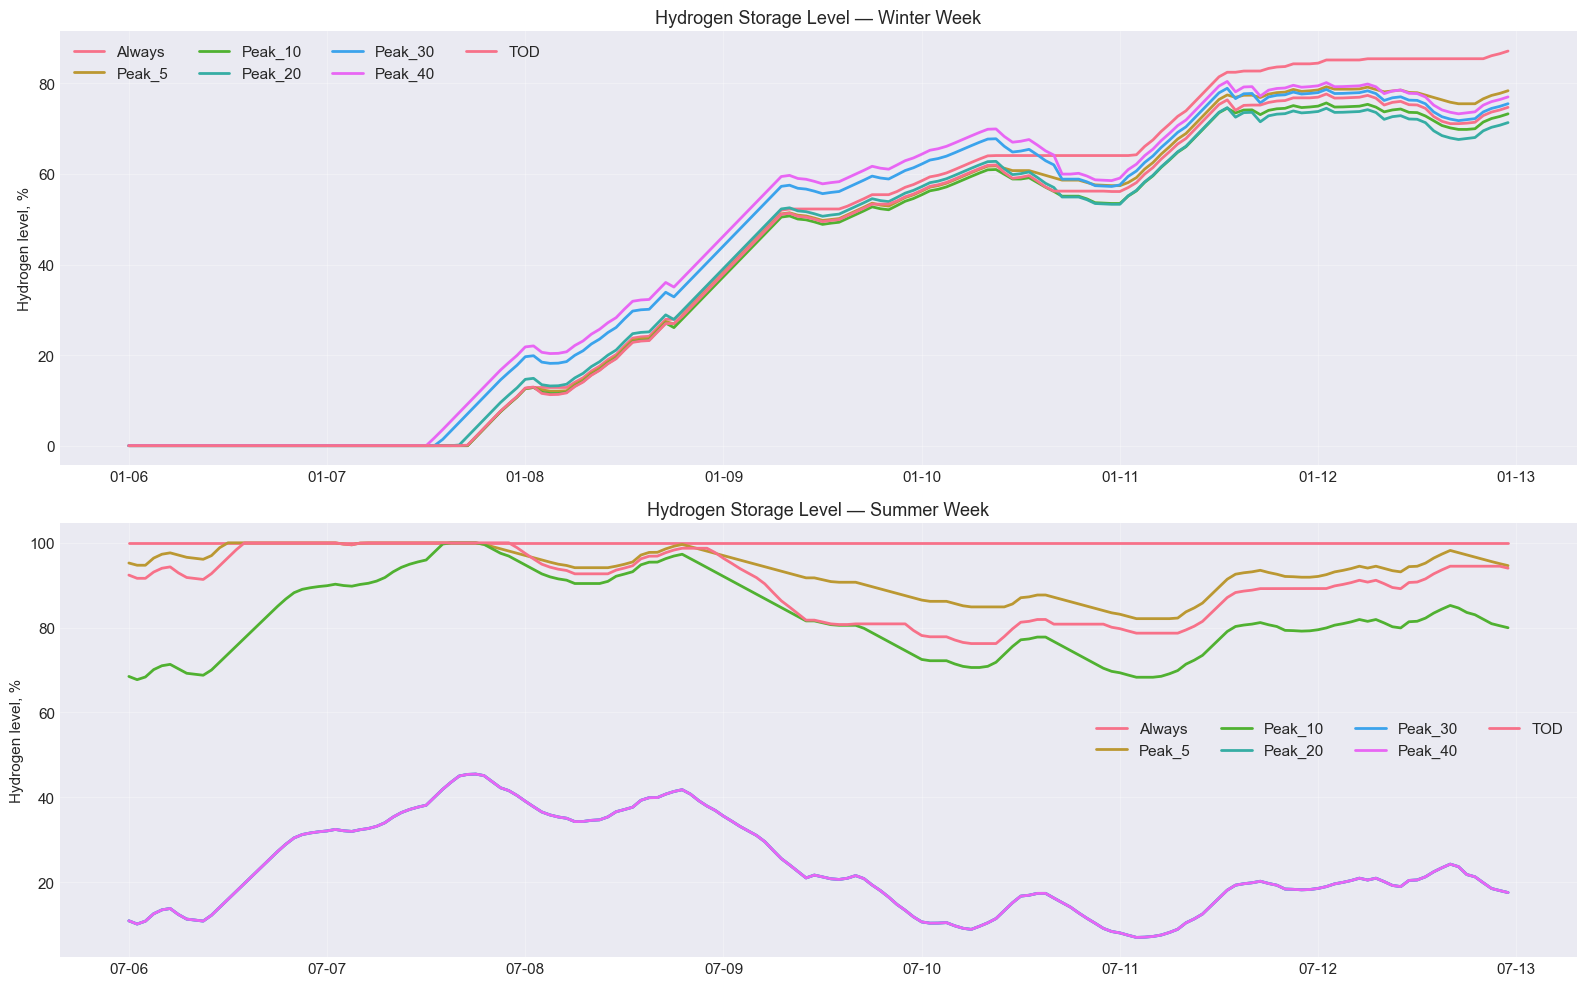

In [27]:
# ГРАФИКИ УРОВНЯ ВОДОРОДНОГО ХРАНИЛИЩА


fig, axes = plt.subplots(

    2, 1,
    figsize=(16, 10)

)


# ЗИМНИЙ ПЕРИОД


ax = axes[0]

for strategy_name in strategies.keys():

    sim = strategies[strategy_name]

    ax.plot(

        sim.loc[winter_period, 'timestamp'],
        sim.loc[winter_period, 'h2_level'] * 100,

        linewidth=2,
        label=strategy_name

    )

ax.set_title(

    'Hydrogen Storage Level — Winter Week'

)

ax.set_ylabel(

    'Hydrogen level, %'

)

ax.legend(

    ncol=4

)

ax.grid(

    True,
    alpha=0.3

)

ax.xaxis.set_major_formatter(

    DateFormatter('%m-%d')

)


# ЛЕТНИЙ ПЕРИОД


ax = axes[1]

for strategy_name in strategies.keys():

    sim = strategies[strategy_name]

    ax.plot(

        sim.loc[summer_period, 'timestamp'],
        sim.loc[summer_period, 'h2_level'] * 100,

        linewidth=2,
        label=strategy_name

    )

ax.set_title(

    'Hydrogen Storage Level — Summer Week'

)

ax.set_ylabel(

    'Hydrogen level, %'

)

ax.legend(

    ncol=4

)

ax.grid(

    True,
    alpha=0.3

)

ax.xaxis.set_major_formatter(

    DateFormatter('%m-%d')

)

plt.tight_layout()

plt.show()

# 14. Анализ работы водородной системы

После анализа аккумуляторной батареи необходимо отдельно рассмотреть работу водородной подсистемы хранения энергии.

Водородная система используется как долгосрочный накопитель энергии и начинает активно работать в следующих случаях:

- аккумуляторная батарея уже полностью заряжена;
- присутствует продолжительный избыток генерации;
- возникает длительный дефицит энергии;
- батарея не может полностью покрыть нагрузку.

Электролизер преобразует избыток электроэнергии в водород, а топливный элемент позволяет вернуть накопленную энергию обратно в систему при дефиците генерации.

Ниже представлены графики мощности электролизера и топливного элемента для различных стратегий управления накопителями.

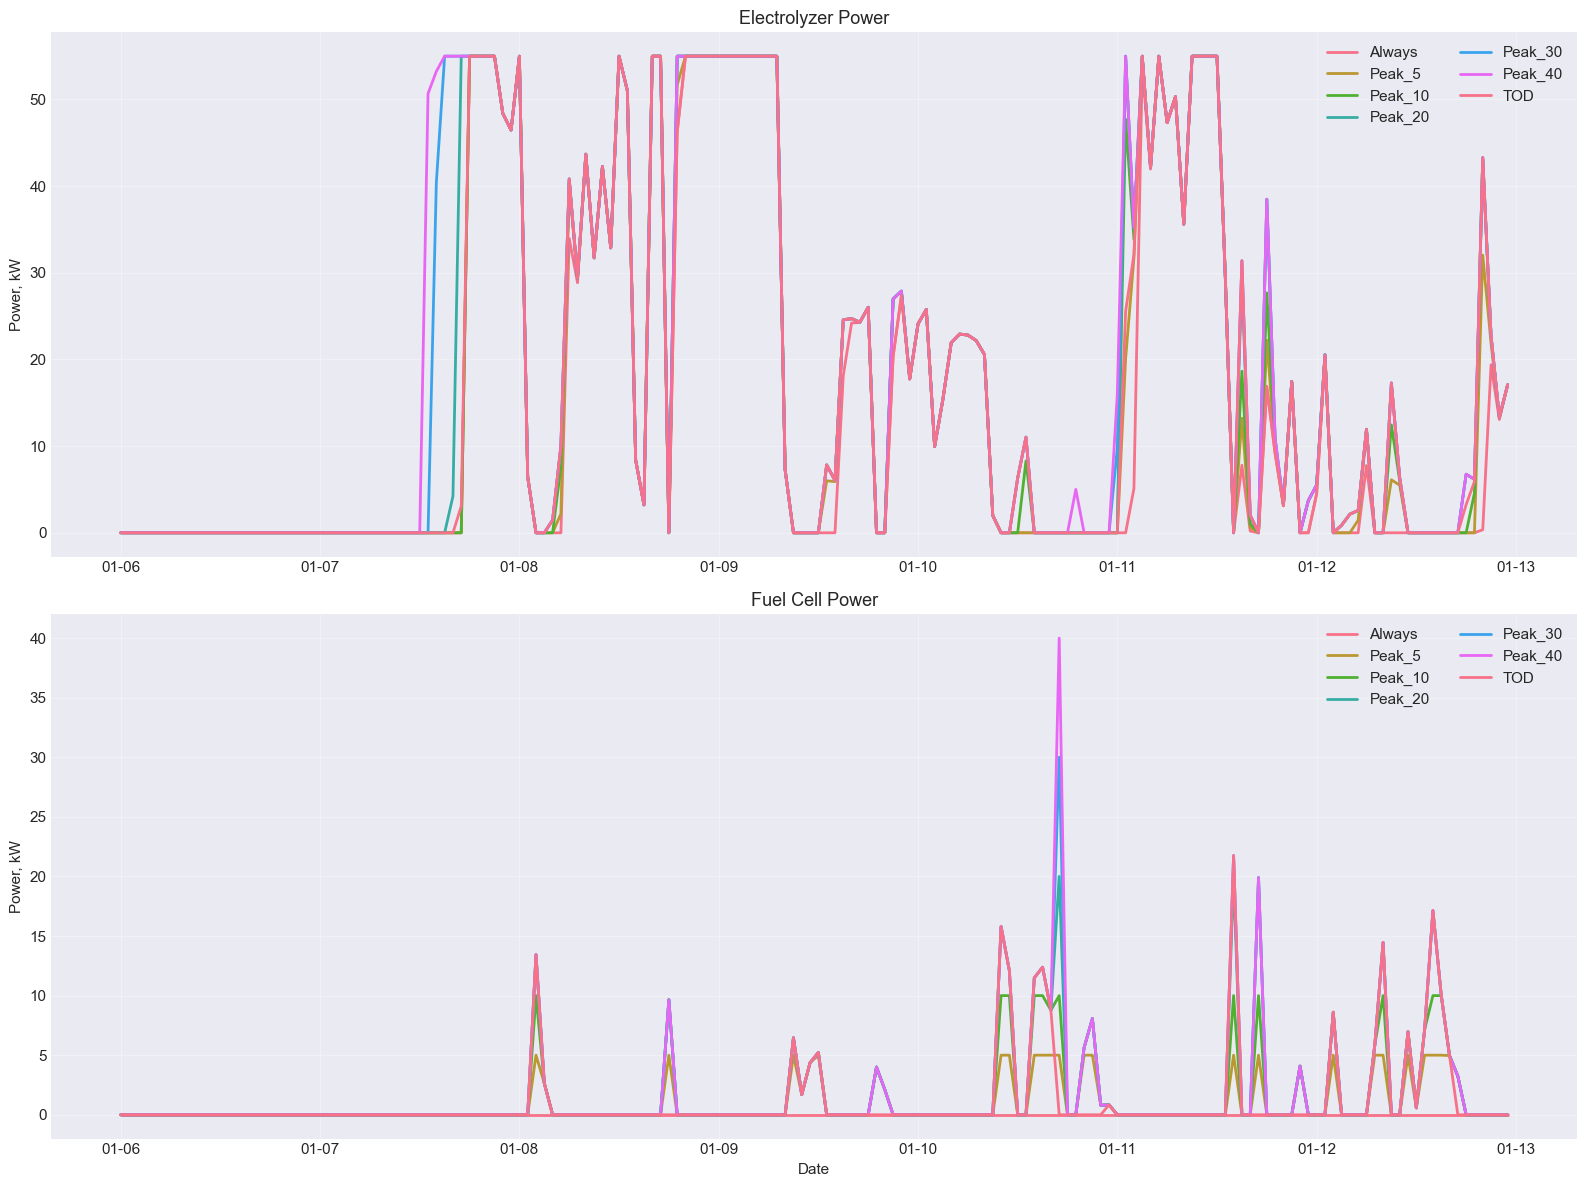

In [28]:
# ГРАФИКИ РАБОТЫ ВОДОРОДНОЙ СИСТЕМЫ


# НЕДЕЛЯ ДЛЯ ДЕТАЛЬНОГО АНАЛИЗА

analysis_period = (

    (df['timestamp'] >= '2020-01-06')
    &
    (df['timestamp'] < '2020-01-13')

)


# СОЗДАНИЕ ГРАФИКОВ


fig, axes = plt.subplots(

    2,
    1,
    figsize=(16, 12)

)


# ELECTROLYZER POWER


ax = axes[0]

for strategy_name in strategies.keys():

    sim = strategies[strategy_name]

    ax.plot(

        sim.loc[analysis_period, 'timestamp'],
        sim.loc[analysis_period, 'electrolyzer_power'],

        linewidth=2,
        label=strategy_name

    )

ax.set_title(

    'Electrolyzer Power'

)

ax.set_ylabel(

    'Power, kW'

)

ax.legend(

    loc='upper right',
    ncol=2

)

ax.grid(

    True,
    alpha=0.3

)

ax.xaxis.set_major_formatter(

    DateFormatter('%m-%d')

)


# FUEL CELL POWER


ax = axes[1]

for strategy_name in strategies.keys():

    sim = strategies[strategy_name]

    ax.plot(

        sim.loc[analysis_period, 'timestamp'],
        sim.loc[analysis_period, 'fuel_cell_power'],

        linewidth=2,
        label=strategy_name

    )

ax.set_title(

    'Fuel Cell Power'

)

ax.set_ylabel(

    'Power, kW'

)

ax.set_xlabel(

    'Date'

)

ax.legend(

    loc='upper right',
    ncol=2

)

ax.grid(

    True,
    alpha=0.3

)

ax.xaxis.set_major_formatter(

    DateFormatter('%m-%d')

)

plt.tight_layout()

plt.show()

# 15. Анализ импорта электроэнергии из внешней сети

Одним из главных критериев эффективности системы управления накопителями является снижение потребления электроэнергии из внешней сети.

Импорт электроэнергии возникает в ситуациях, когда:
- генерации ВИЭ недостаточно для покрытия нагрузки;
- батарея разряжена;
- водородное хранилище не может обеспечить необходимую мощность;
- стратегия управления ограничивает использование накопителей.

Ниже представлены:
- временные профили импорта мощности,
- сезонное распределение потребления энергии из сети,
- сравнение общего объема импорта между стратегиями.

Анализ позволяет определить:
- насколько эффективно стратегии снижают зависимость микросети от внешней сети;
- в какие периоды наблюдаются наибольшие дефициты энергии;
- как влияет стратегия управления на сезонную устойчивость системы.

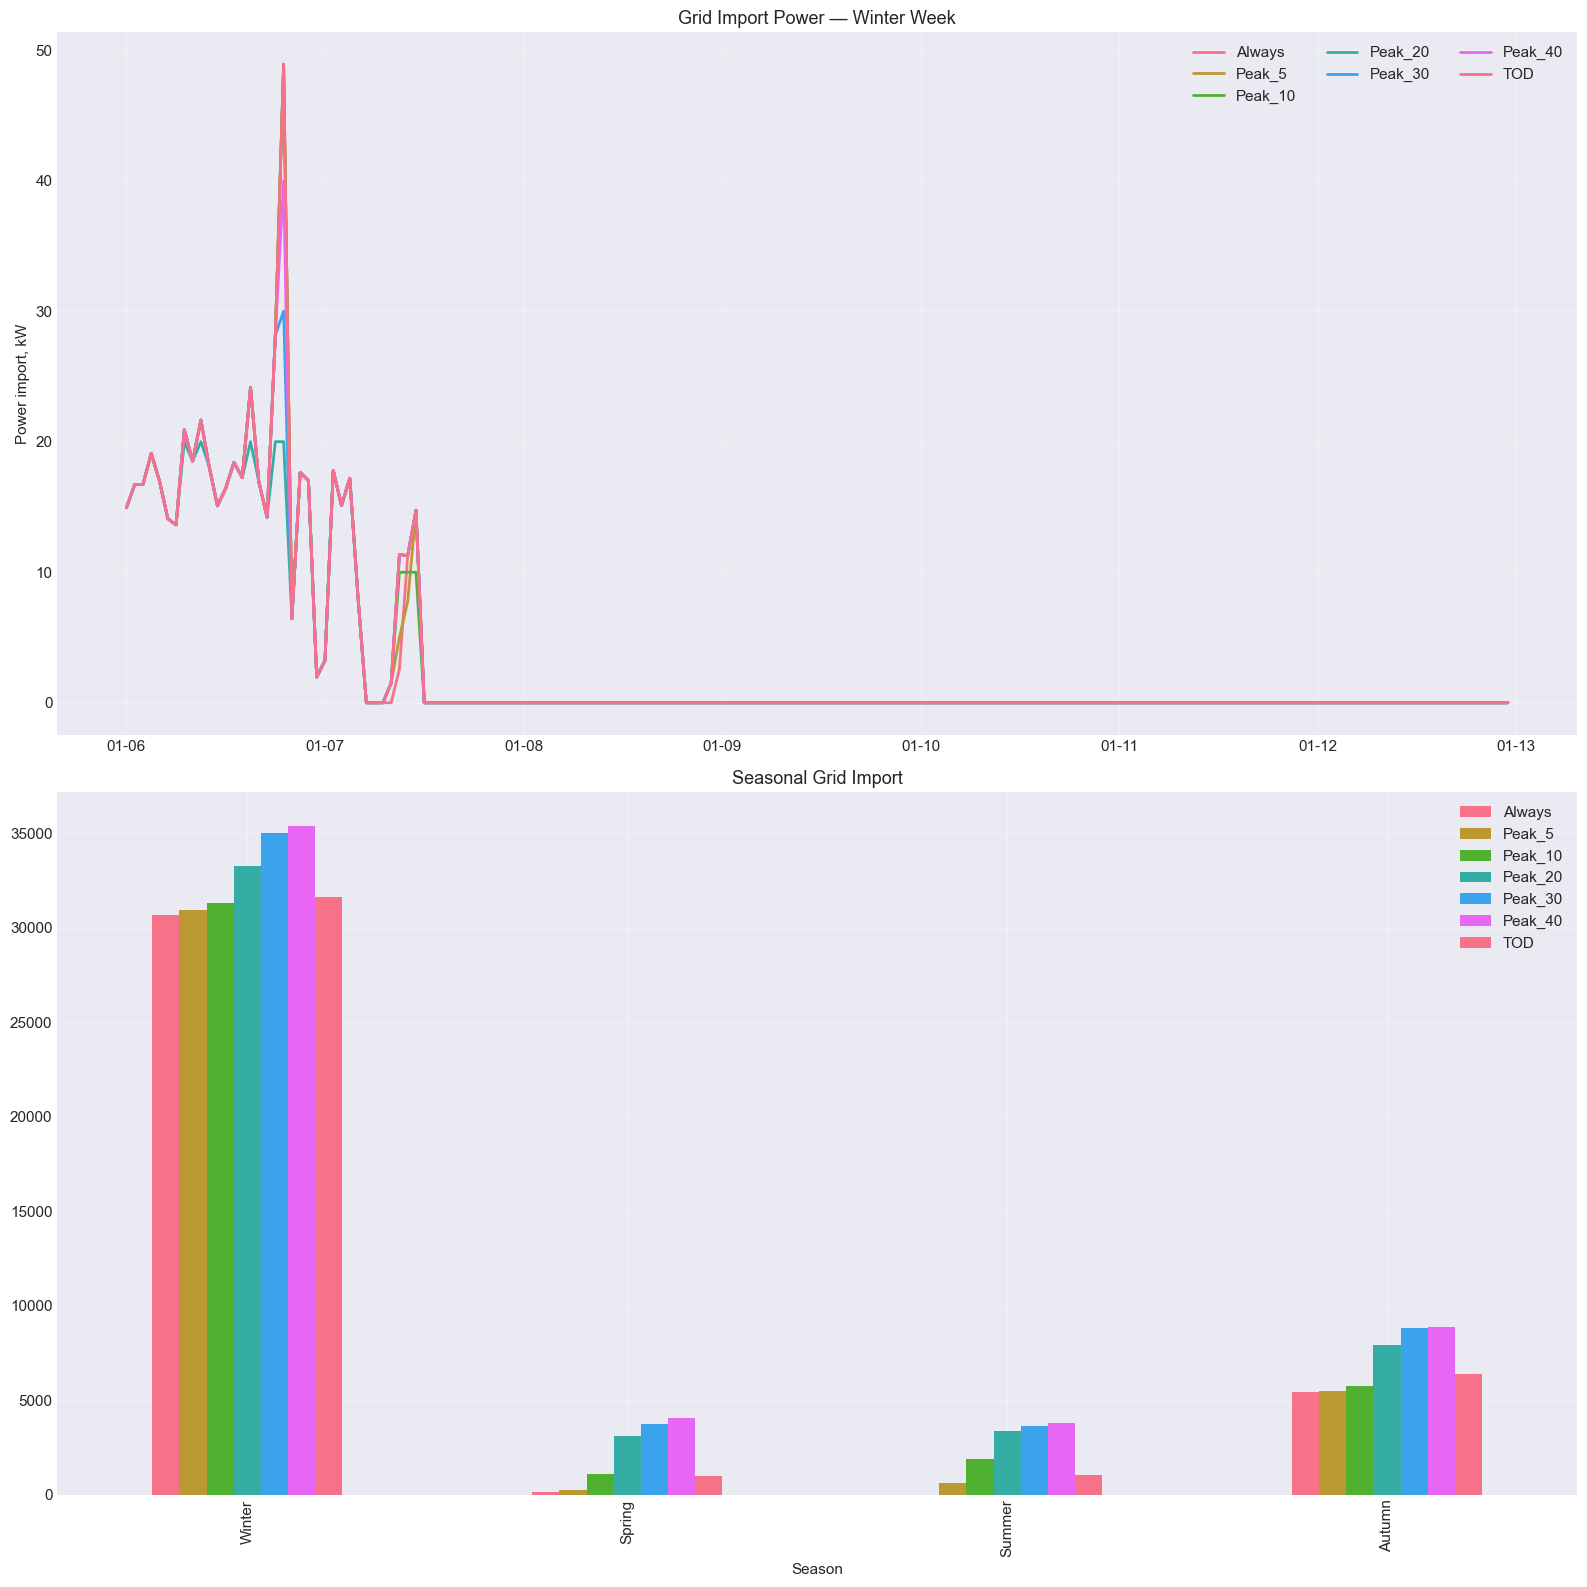

In [29]:
# ГРАФИКИ ИМПОРТА ЭЛЕКТРОЭНЕРГИИ ИЗ СЕТИ


fig, axes = plt.subplots(

    2,
    1,
    figsize=(16, 16)

)


# 1. ИМПОРТ МОЩНОСТИ — ЗИМНЯЯ НЕДЕЛЯ


ax = axes[0]

for strategy_name in strategies.keys():

    sim = strategies[strategy_name]

    ax.plot(

        sim.loc[winter_period, 'timestamp'],
        sim.loc[winter_period, 'grid_import'],

        linewidth=2,
        label=strategy_name

    )

ax.set_title(

    'Grid Import Power — Winter Week'

)

ax.set_ylabel(

    'Power import, kW'

)

ax.legend(

    ncol=3

)

ax.grid(

    True,
    alpha=0.3

)

ax.xaxis.set_major_formatter(

    DateFormatter('%m-%d')

)


# 2. СЕЗОННЫЙ ИМПОРТ ЭНЕРГИИ


ax = axes[1]

seasonal_import = pd.DataFrame()

for strategy_name in strategies.keys():

    sim = strategies[strategy_name]

    seasonal_import[strategy_name] = (

        sim.groupby('season')['grid_import']
        .sum()

    )

seasonal_import = seasonal_import.loc[

    ['Winter', 'Spring', 'Summer', 'Autumn']

]

seasonal_import.plot(

    kind='bar',
    ax=ax

)

ax.set_title(

    'Seasonal Grid Import'

)


ax.set_xlabel(

    'Season'

)

ax.grid(

    True,
    alpha=0.3

)

plt.tight_layout()

plt.show()

# 16. Сравнение работы стратегий управления накопителями

Для итогового анализа эффективности различных алгоритмов управления накопителями необходимо сравнить:
- уровень использования батареи,
- интенсивность работы водородной системы,
- объем импорта энергии из сети,
- общую стоимость эксплуатации.

Дополнительно важным параметром является количество циклов зарядки и разрядки аккумуляторной батареи.

Частое циклирование батареи:
- увеличивает износ накопителя,
- сокращает срок службы,
- повышает эксплуатационные затраты.

Ниже представлены сравнительные показатели для всех стратегий управления.

In [30]:
# ДОПОЛНИТЕЛЬНЫЕ ПОКАЗАТЕЛИ ЭФФЕКТИВНОСТИ


battery_cycles = []

hydrogen_usage = []

for strategy_name in results_df['Strategy']:

    sim = strategies[strategy_name]

    
    # КОЛИЧЕСТВО ЦИКЛОВ БАТАРЕИ
   

    throughput = (

        np.abs(sim['battery_power']).sum()

    )

    equivalent_cycles = (

        throughput
        / (2 * BATTERY_CAPACITY)

    )

    battery_cycles.append(

        equivalent_cycles

    )

    
    # ИСПОЛЬЗОВАНИЕ ВОДОРОДНОЙ СИСТЕМЫ
    

    total_h2_usage = (

        sim['fuel_cell_power'].sum()

    )

    hydrogen_usage.append(

        total_h2_usage

    )


# ДОБАВЛЕНИЕ В ТАБЛИЦУ


results_df['Battery cycles'] = battery_cycles

results_df['Hydrogen usage (kWh)'] = hydrogen_usage


# ВЫВОД ТАБЛИЦЫ


display(

    results_df.round(2)

)

,Strategy,Grid import (kWh),Energy cost (NOK),Peak cost (NOK),Total cost (NOK),Average import price (NOK/kWh),Battery cycles,Hydrogen usage (kWh)
0,Peak_30,51226.00,13798.80,34923.98,48722.79,0.95,7.64,37881.67
1,Peak_40,52134.20,13978.60,37759.77,51738.37,0.99,4.47,38447.03
2,Always,36259.58,11196.16,47764.14,58960.30,1.63,92.12,13852.64
3,Peak_20,47700.46,13070.83,47898.96,60969.79,1.28,19.31,35966.00
4,Peak_10,40072.59,11795.66,50001.05,61796.71,1.54,48.95,29896.51
5,Peak_5,37320.81,11392.93,50441.77,61834.70,1.66,70.52,22730.67
6,TOD,40105.37,11891.93,70495.83,82387.76,2.05,57.20,26099.16


# 17. Итоговые выводы по результатам моделирования

На заключительном этапе выполняется автоматический анализ результатов моделирования.

Сравниваются:
- стоимость эксплуатации,
- импорт электроэнергии,
- интенсивность использования батареи,
- работа водородной системы.

На основе полученных результатов определяется наиболее эффективная стратегия управления накопителями энергии.

In [31]:
# ЛУЧШАЯ И ХУДШАЯ СТРАТЕГИЯ


best_strategy = results_df.iloc[0]

worst_strategy = results_df.iloc[-1]


# ЭКОНОМИЯ


savings_percent = (

    (
        worst_strategy['Total cost (NOK)']
        - best_strategy['Total cost (NOK)']
    )
    /
    worst_strategy['Total cost (NOK)']

    * 100

)


# ВЫВОД РЕЗУЛЬТАТОВ


print('FINAL RESULTS')


print()


# ЛУЧШАЯ СТРАТЕГИЯ


print('BEST STRATEGY')


print(

    f"Strategy: {best_strategy['Strategy']}"

)

print(

    f"Total cost: {best_strategy['Total cost (NOK)']:.2f} NOK"

)

print(

    f"Grid import: {best_strategy['Grid import (kWh)']:.2f} kWh"

)

print(

    f"Battery cycles: {best_strategy['Battery cycles']:.2f}"

)

print(

    f"Hydrogen usage: {best_strategy['Hydrogen usage (kWh)']:.2f} kWh"

)

print()


# ХУДШАЯ СТРАТЕГИЯ


print('WORST STRATEGY')


print(

    f"Strategy: {worst_strategy['Strategy']}"

)

print(

    f"Total cost: {worst_strategy['Total cost (NOK)']:.2f} NOK"

)

print()


# ЭКОНОМИЯ


print('ECONOMIC EFFECT')


print(

    f'Savings: {savings_percent:.2f}%'

)

print()

FINAL RESULTS

BEST STRATEGY
Strategy: Peak_30
Total cost: 48722.79 NOK
Grid import: 51226.00 kWh
Battery cycles: 7.64
Hydrogen usage: 37881.67 kWh

WORST STRATEGY
Strategy: TOD
Total cost: 82387.76 NOK

ECONOMIC EFFECT
Savings: 40.86%

